In [1]:
from google.colab import files

uploaded = files.upload()

for fn in uploaded.keys():
  print('User uploaded file "{name}" with length {length} bytes'.format(
      name=fn, length=len(uploaded[fn])))

Saving 2.csv to 2.csv
User uploaded file "2.csv" with length 20658 bytes


--- 1. Preprocessing Data ---
Normalized 'Age' and 'BMI' using Z-score.
   ParticipantID       Age       BMI
0              1  0.163672 -0.362840
1              2  0.792784  0.977804
2              4  1.421896  0.519163
3              5 -0.105948  1.401166
4              6 -1.543919 -1.632925
Randomization complete. Assigned 246 participants to 5 groups.

               BALANCE METRICS FOR INITIAL RANDOMIZATION

Overall Group Sizes:
Assigned_Group
Group 1    50
Group 2    46
Group 3    49
Group 4    49
Group 5    52
Name: count, dtype: int64

--- Categorical Balance ---

--- Balance for 'W_Strat' ---
Assigned_Group  Group 1  Group 2  Group 3  Group 4  Group 5
W_Strat                                                    
Healthy              24       22       22       22       25
Obese                26       24       27       27       27
Chi-Squared Test: chi2=0.22, p-value=0.994
Average Cross-Entropy: 1.6107 (lower is better)

--- Balance for 'C_Strat' ---
Assigned_Group  Group 1  Group

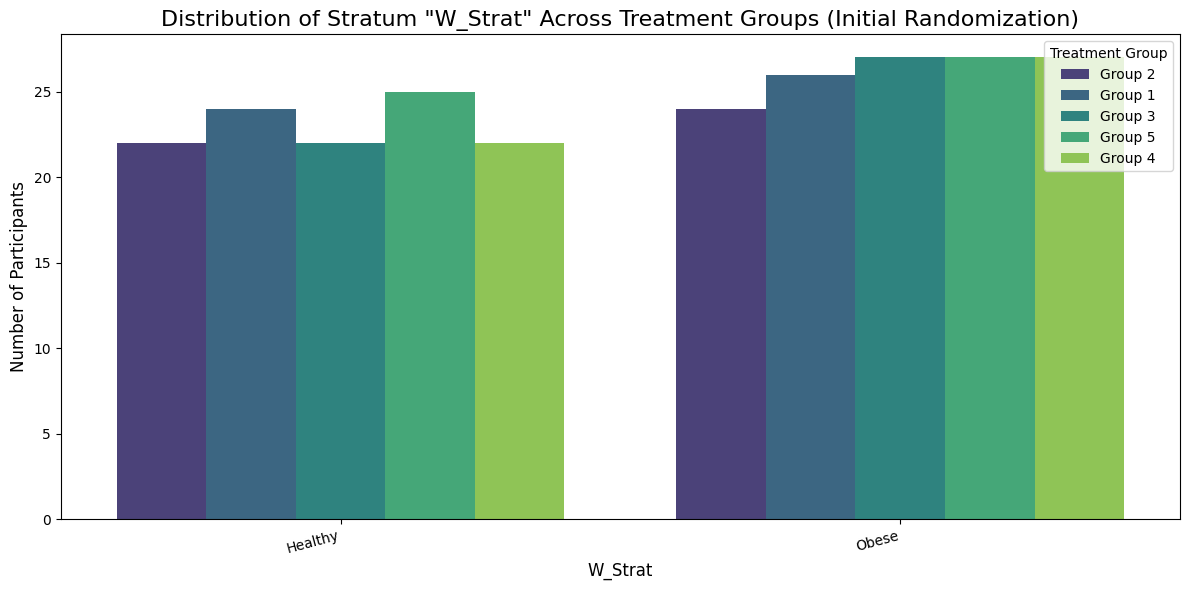

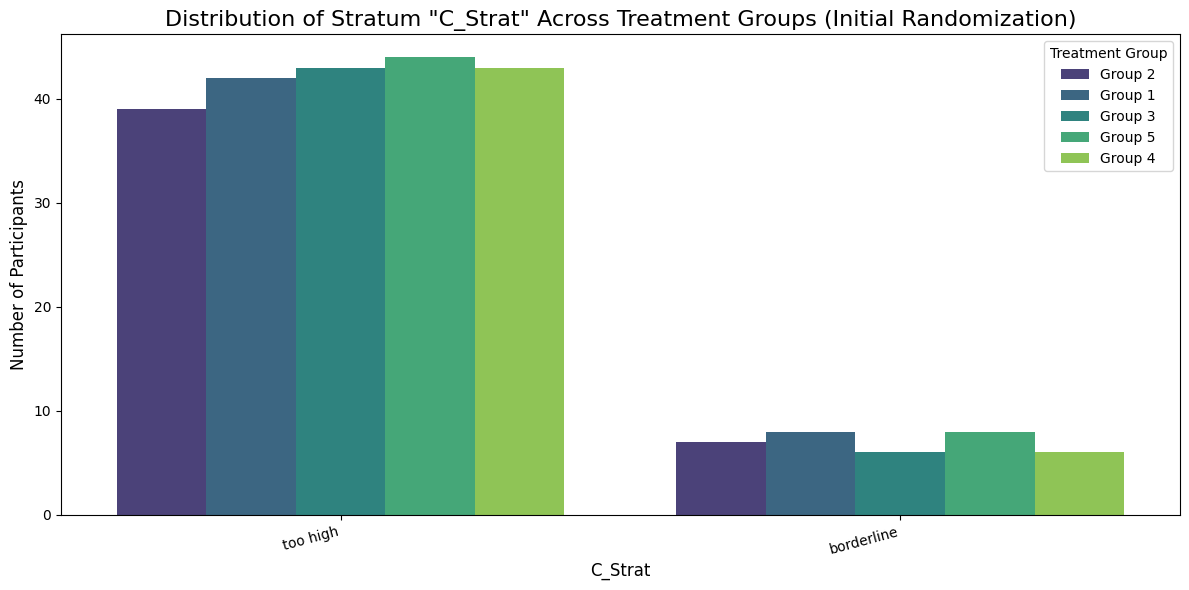

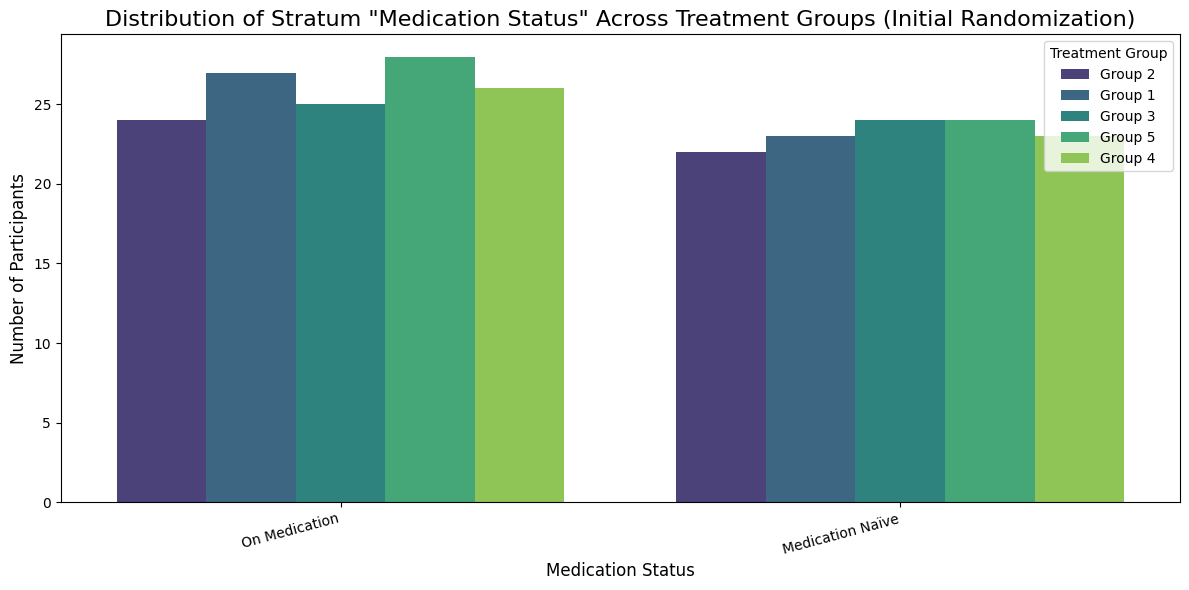

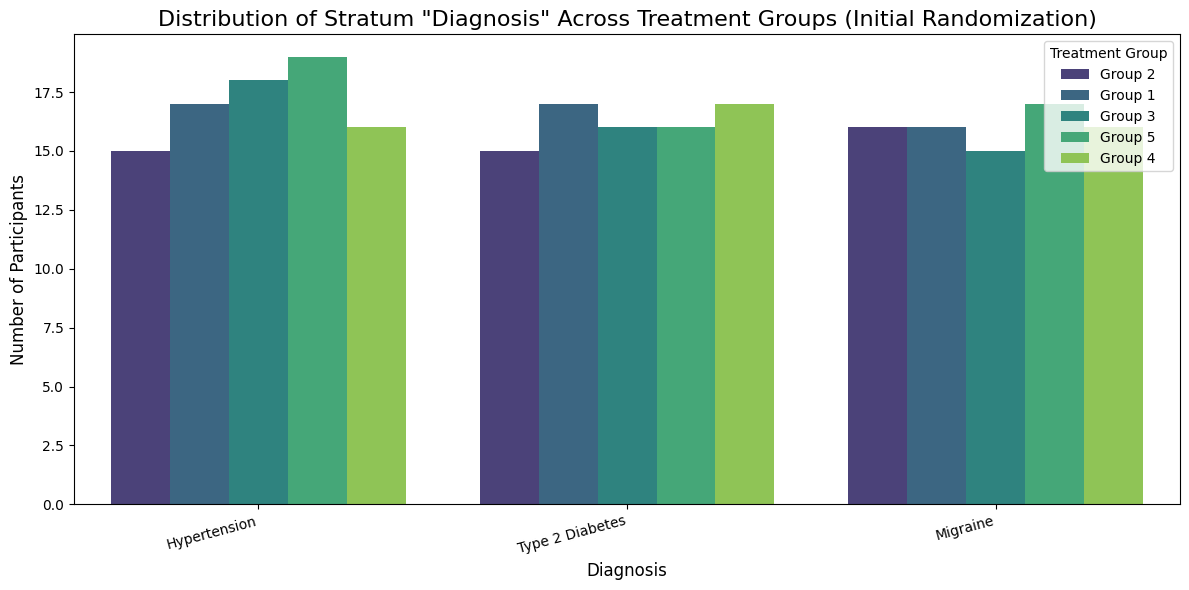

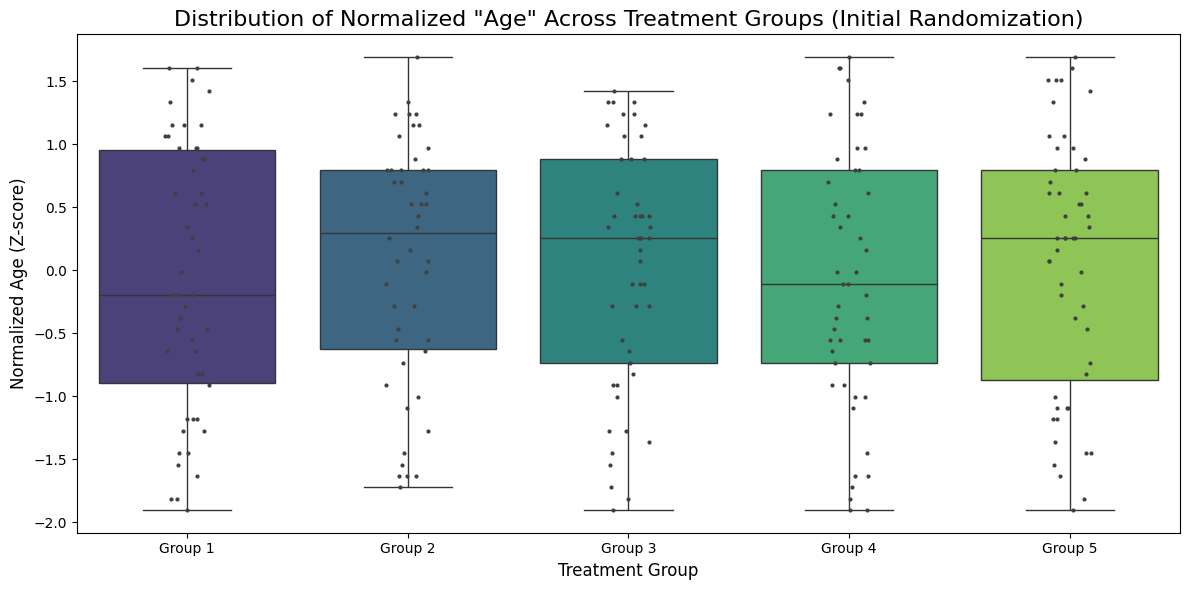

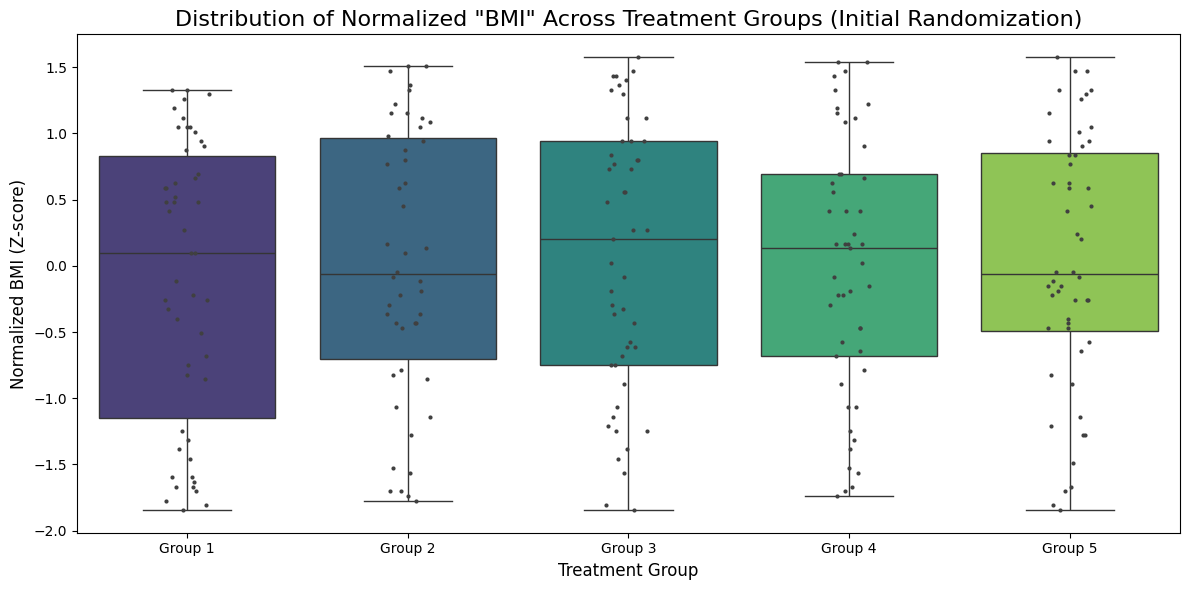


--- Initial Randomization Workflow Complete. ---
Randomized data saved to 'randomized_participants.csv'.
Randomized Data Head:
   ParticipantID              Name  W_Strat   C_Strat Medication Status  \
0              1  Michael Thompson  Healthy  too high     On Medication   
1              2    Jessica Garcia    Obese  too high  Medication Naïve   
2              4       Laura Davis    Obese  too high     On Medication   
3              5    David Martinez    Obese  too high  Medication Naïve   
4              6       Emily Brown  Healthy  too high     On Medication   

         Diagnosis Assigned_Group  
0     Hypertension        Group 2  
1  Type 2 Diabetes        Group 2  
2     Hypertension        Group 1  
3  Type 2 Diabetes        Group 3  
4         Migraine        Group 1  


In [8]:
# --- Workflow 1: Initial Randomization and Validation ---

INPUT_FILENAME = '/content/2.csv'
OUTPUT_FILENAME = 'randomized_participants.csv'
CATEGORICAL_STRATA = ['W_Strat', 'C_Strat', 'Medication Status', 'Diagnosis']
CONTINUOUS_COVARIATES = ['Age', 'BMI']
NUM_TREATMENT_GROUPS = 5

try:
    # 1. Preprocess data
    preprocessed_df = preprocess_data(INPUT_FILENAME)

    # 2. Run randomization
    randomized_df = map_coloring_randomization(
        preprocessed_df.copy(), # Use a copy to avoid modifying the original preprocessed_df
        strata_vars=CATEGORICAL_STRATA,
        num_groups=NUM_TREATMENT_GROUPS
    )

    # 3. Calculate balance metrics
    print("\n" + "="*80)
    print(" " * 15 + "BALANCE METRICS FOR INITIAL RANDOMIZATION")
    print("="*80)
    calculate_balance_metrics(
        randomized_df,
        strata_vars=CATEGORICAL_STRATA,
        continuous_vars=CONTINUOUS_COVARIATES,
        num_groups=NUM_TREATMENT_GROUPS
    )

    # 4. Visualize the results
    visualize_balance(
        randomized_df,
        strata_vars=CATEGORICAL_STRATA,
        continuous_vars=CONTINUOUS_COVARIATES,
        title_suffix=" (Initial Randomization)"
    )

    # 5. Save the final randomized dataframe
    randomized_df.to_csv(OUTPUT_FILENAME, index=False)
    print(f"\n--- Initial Randomization Workflow Complete. ---")
    print(f"Randomized data saved to '{OUTPUT_FILENAME}'.")
    print("Randomized Data Head:")
    print(randomized_df[['ParticipantID', 'Name'] + CATEGORICAL_STRATA + ['Assigned_Group']].head())

except FileNotFoundError:
    print(f"\nERROR: The file '{INPUT_FILENAME}' was not found.")
    print("Please make sure you have uploaded the file to your Colab session.")
except KeyError as e:
    print(f"\nERROR: A required column was not found: {e}")
    print("Please check your CSV file's column headers.")

--- 1. Preprocessing Data ---
Normalized 'Age' and 'BMI' using Z-score.
   ParticipantID       Age       BMI
0              1  0.163672 -0.362840
1              2  0.792784  0.977804
2              4  1.421896  0.519163
3              5 -0.105948  1.401166
4              6 -1.543919 -1.632925

--- 2. Running Randomization on Full Cohort ---
Randomization complete. Assigned 246 participants to 5 groups.

               METRICS FOR FULL COHORT (BEFORE DROPOUT)

Overall Group Sizes:
Assigned_Group
Group 1    49
Group 2    49
Group 3    49
Group 4    50
Group 5    49
Name: count, dtype: int64

--- Categorical Balance ---

--- Balance for 'W_Strat' ---
Assigned_Group  Group 1  Group 2  Group 3  Group 4  Group 5
W_Strat                                                    
Healthy              23       23       24       23       22
Obese                26       26       25       27       27
Chi-Squared Test: chi2=0.18, p-value=0.996
Average Cross-Entropy: 1.6098 (lower is better)

--- Balance 

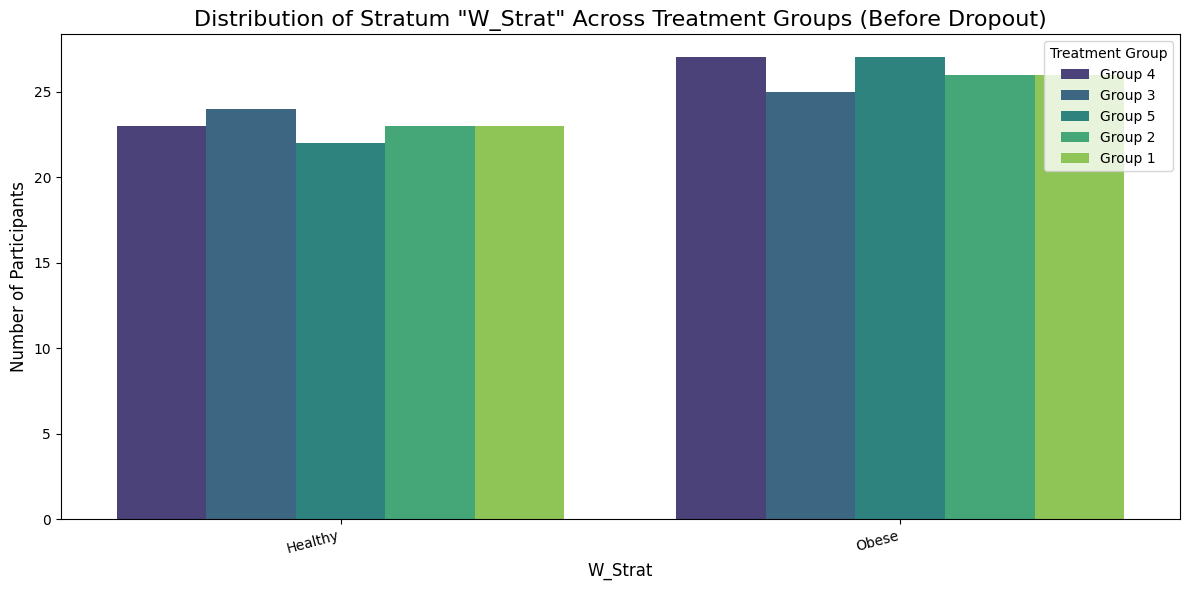

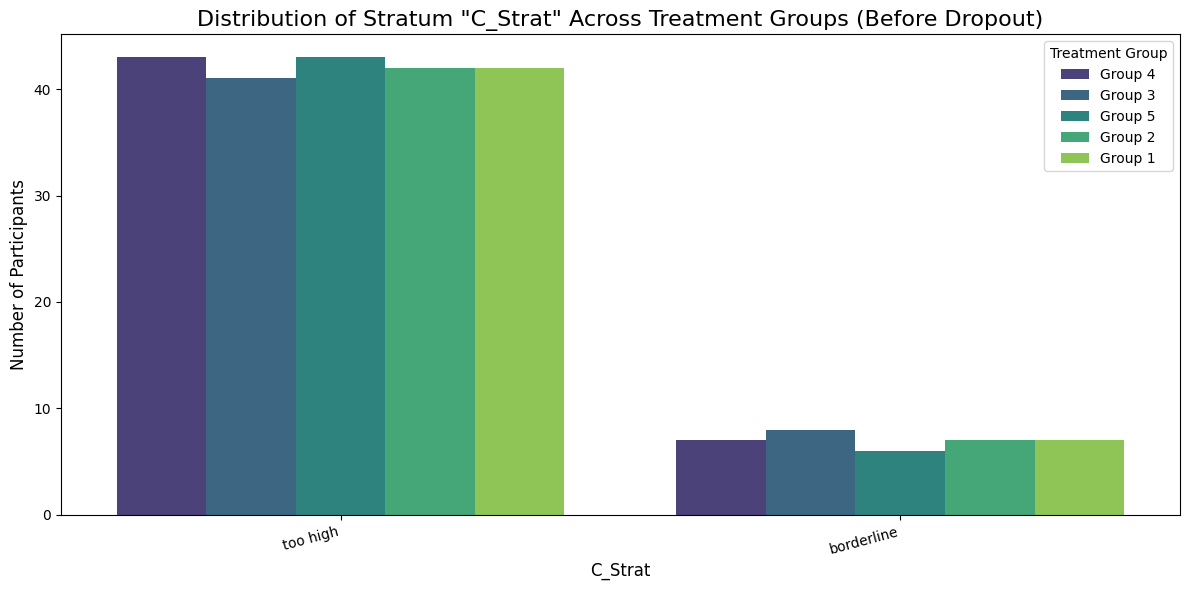

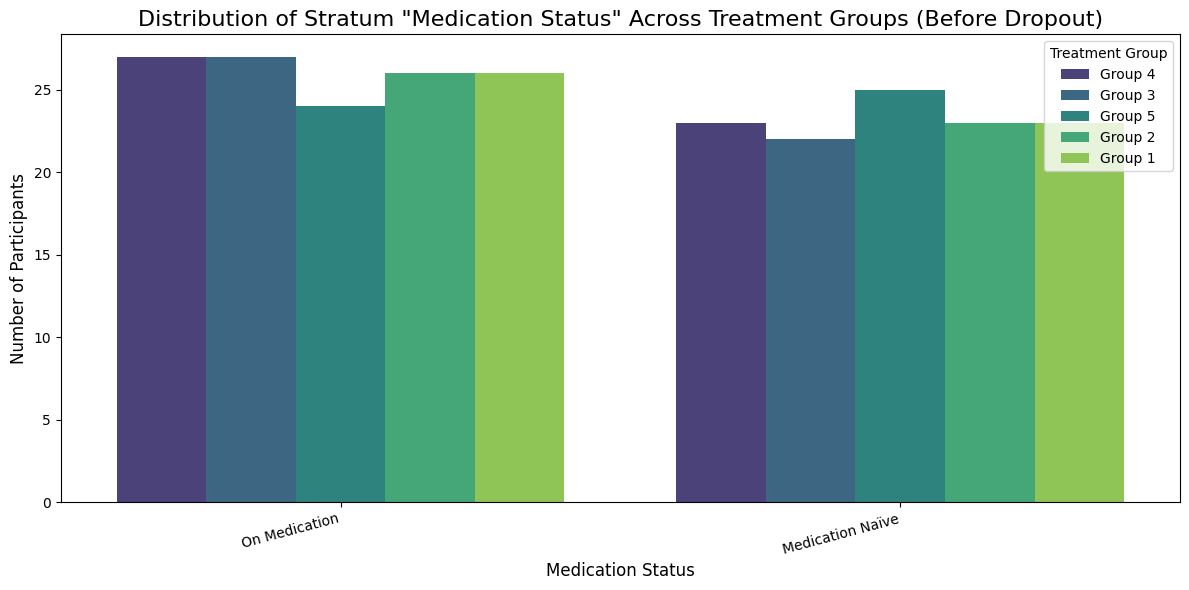

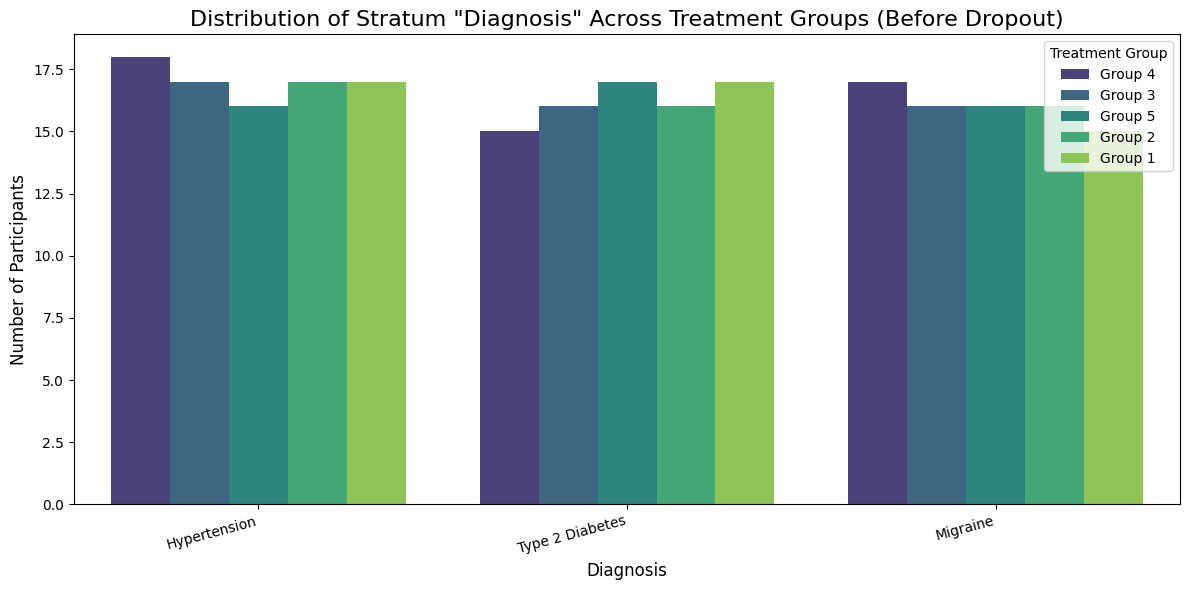

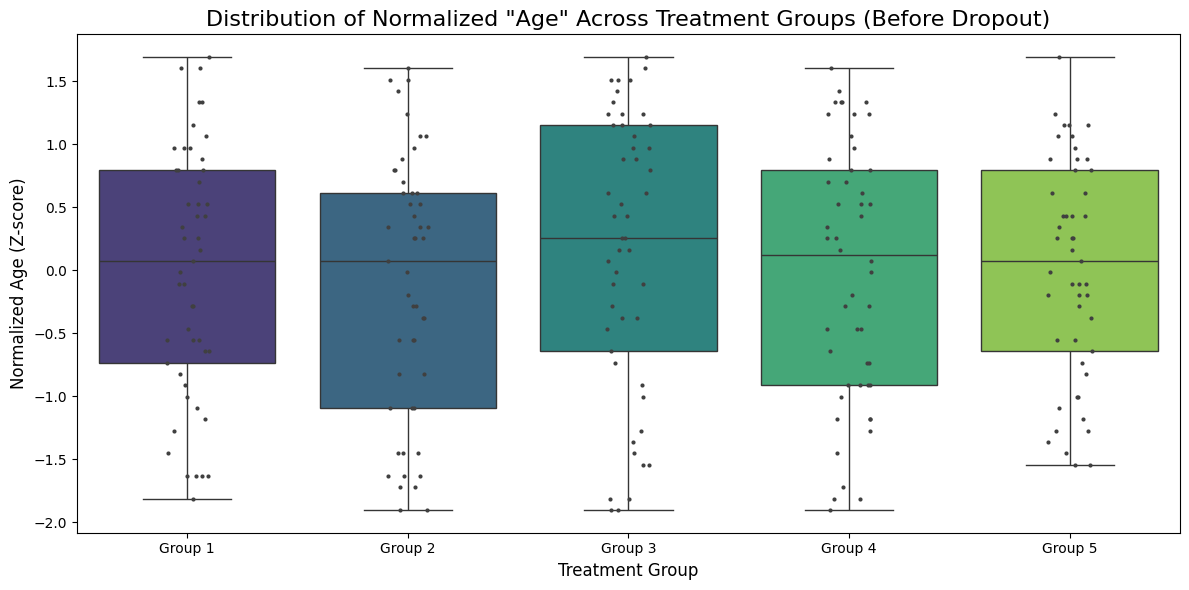

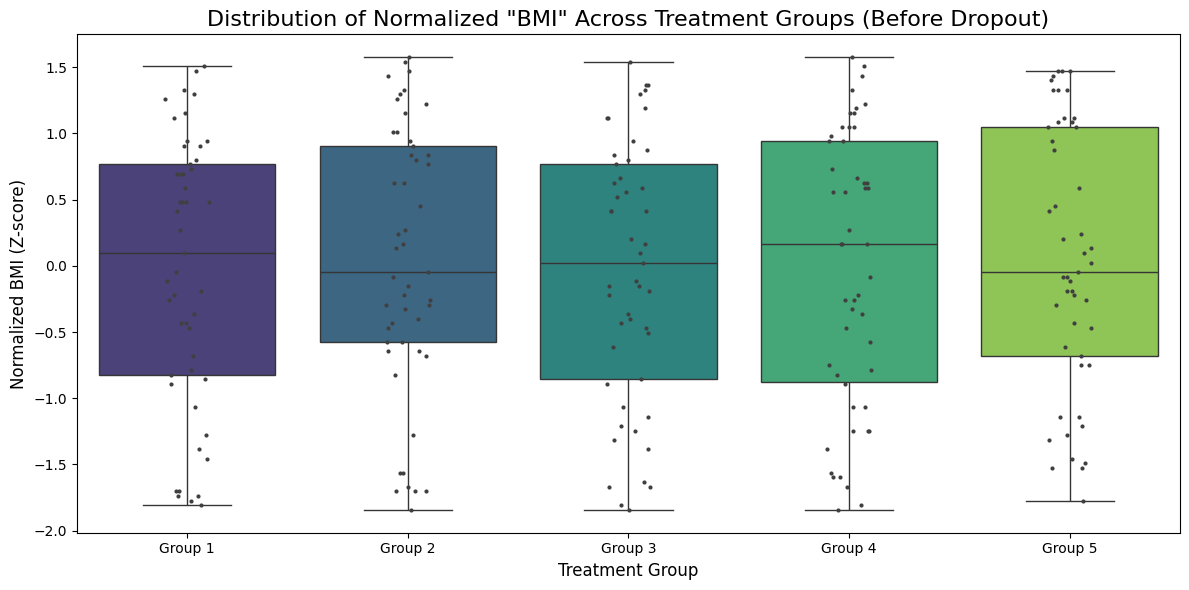


--- 5. Visualizing Balance for Remaining Cohort (After Dropout) ---

--- Generating Visualizations (After Dropout) ---


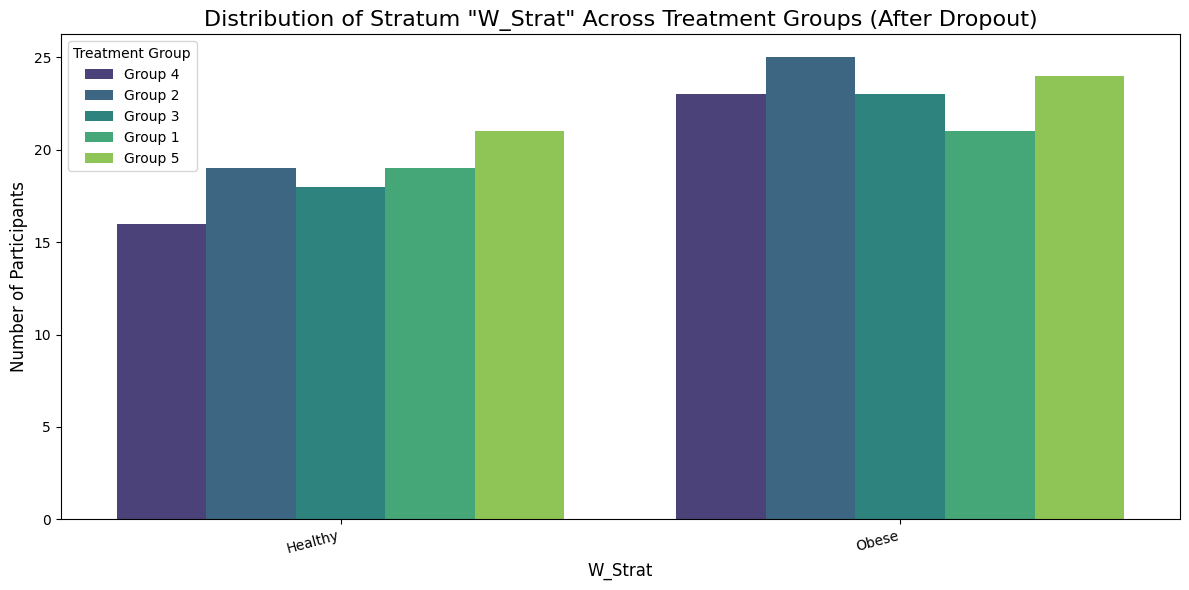

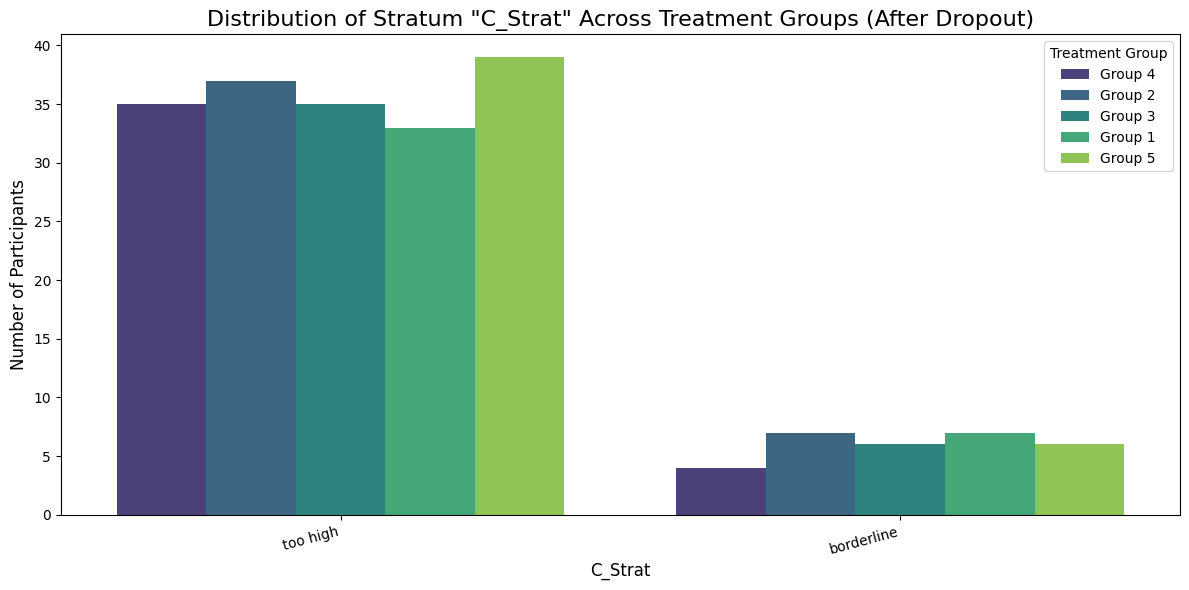

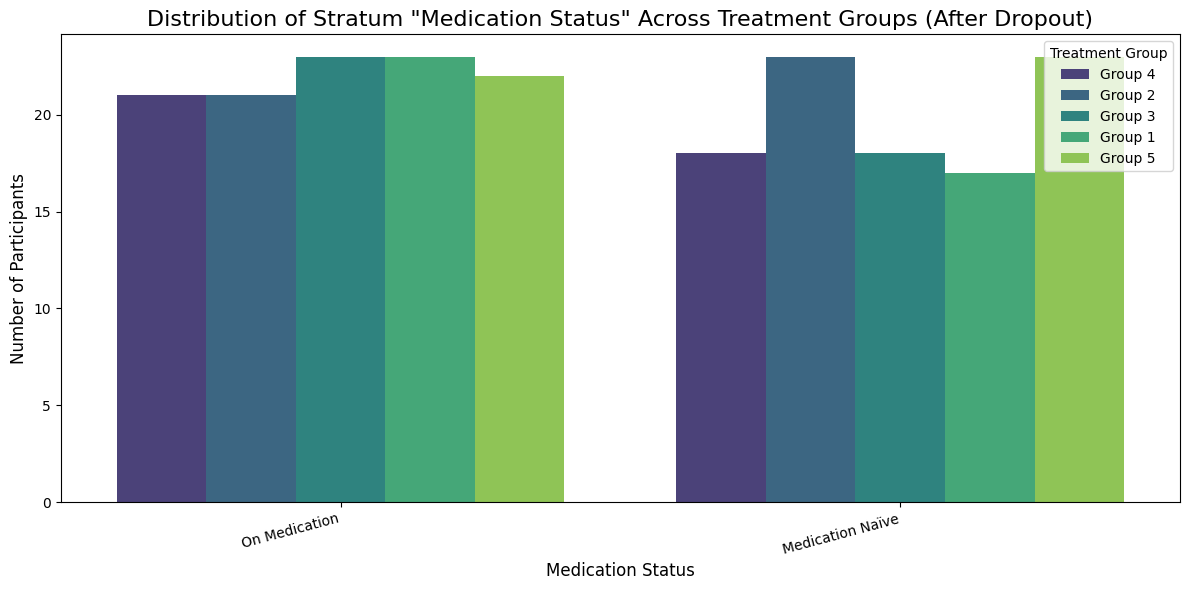

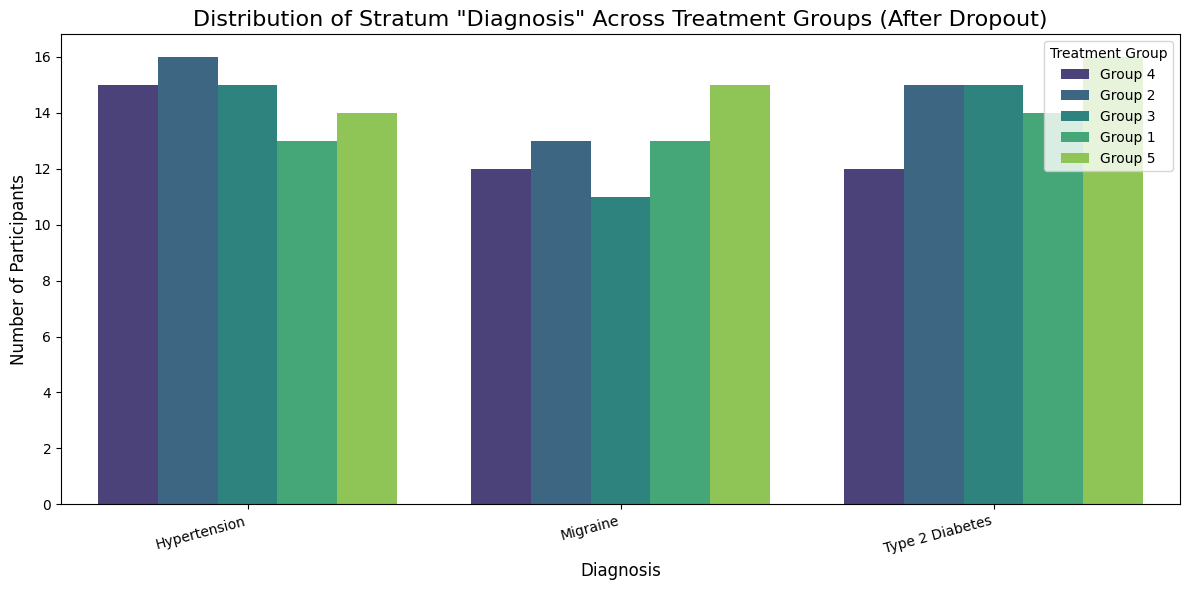

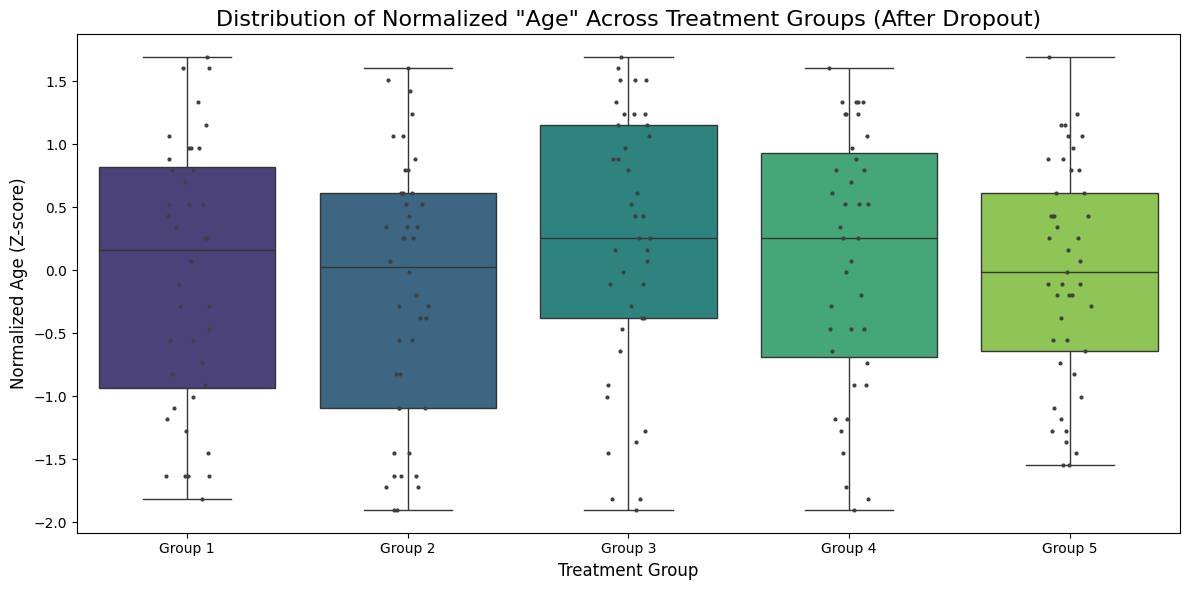

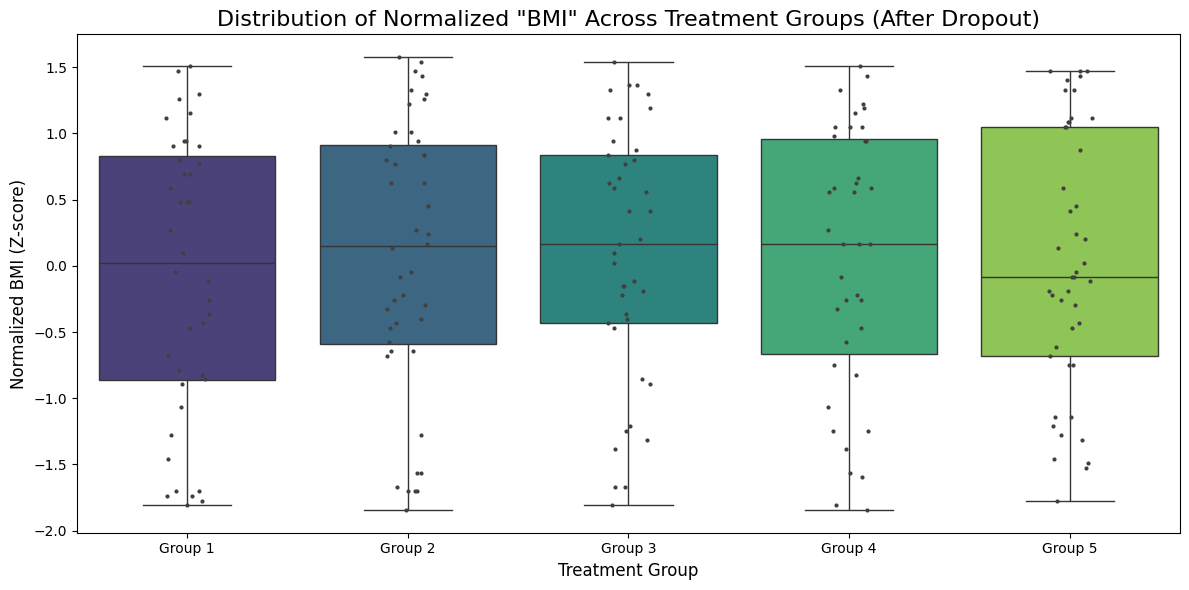


--- Pipeline Complete. ---
Full, ideal randomized data (before simulating dropouts) saved to 'randomized_participants.csv'.
Final Randomized Data Head:
   ParticipantID              Name  W_Strat   C_Strat Medication Status  \
0              1  Michael Thompson  Healthy  too high     On Medication   
1              2    Jessica Garcia    Obese  too high  Medication Naïve   
2              4       Laura Davis    Obese  too high     On Medication   
3              5    David Martinez    Obese  too high  Medication Naïve   
4              6       Emily Brown  Healthy  too high     On Medication   

         Diagnosis Assigned_Group  
0     Hypertension        Group 4  
1  Type 2 Diabetes        Group 4  
2     Hypertension        Group 3  
3  Type 2 Diabetes        Group 5  
4         Migraine        Group 3  


In [7]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from scipy.stats import chi2_contingency, f_oneway
from scipy.spatial.distance import pdist, squareform
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Suppress pandas warnings for cleaner output
warnings.filterwarnings('ignore', category=FutureWarning)

# --- INSTRUCTIONS FOR GOOGLE COLAB ---
# 1. Upload your CSV file ('/content/2.csv') to your Colab session.
# 2. Run this entire script cell.
# 3. The script will output balance statistics for the full cohort and for the cohort after simulating dropouts.
# 4. A new file 'randomized_participants.csv' will be created and can be downloaded.

# --- Part 1: Data Preprocessing & Covariate Normalization ---
def preprocess_data(file_path):
    """
    Loads, cleans, preprocesses, and normalizes the participant data.
    """
    print("--- 1. Preprocessing Data ---")
    df = pd.read_csv(file_path)

    # Drop participants who are not enrolled
    df = df[df['Enrollment Status'] == 'Enrolled'].reset_index(drop=True)

    # Define cholesterol stratification
    def stratify_cholesterol(level):
        if level < 100: return 'ideal'
        if 100 <= level <= 160: return 'borderline'
        return 'too high'

    df['C_Strat'] = df['Cholesterol Level (mg/dL)'].apply(stratify_cholesterol)

    # Normalize continuous covariates using z-score
    continuous_covariates = ['Age', 'BMI']
    scaler = StandardScaler()
    df[continuous_covariates] = scaler.fit_transform(df[continuous_covariates])
    print("Normalized 'Age' and 'BMI' using Z-score.")
    print(df[['ParticipantID', 'Age', 'BMI']].head())
    return df

# --- Part 3: Map Coloring-Based Assignment ---
def map_coloring_randomization(df, strata_vars, num_groups=5):
    """
    Performs stratified randomization using a map coloring analogy.
    Each unique combination of strata is a "region". Participants within each
    region are assigned "colors" (treatment groups) to ensure balance.
    This is equivalent to permuted block randomization within each stratum.
    """
    treatment_groups = [f'Group {i+1}' for i in range(num_groups)]
    assignments = pd.Series(index=df.index, dtype=str)

    # Create a composite stratum ("region") for each participant
    # This combines all stratification variables into a single identifier
    composite_strata = df[strata_vars].apply(lambda x: '_'.join(x.astype(str)), axis=1)

    # Iterate over each unique "region"
    for stratum in composite_strata.unique():
        # Get the indices of all participants in the current region
        participant_indices_in_stratum = df[composite_strata == stratum].index.tolist()

        # Randomly shuffle the order of participants within the region
        np.random.shuffle(participant_indices_in_stratum)

        # Create a balanced, shuffled block of treatment assignments ("colors")
        num_participants = len(participant_indices_in_stratum)
        block_size = num_groups

        # Generate enough full blocks to cover all participants
        num_blocks = (num_participants + block_size - 1) // block_size
        assignment_block = []
        for _ in range(num_blocks):
            shuffled_groups = treatment_groups.copy()
            np.random.shuffle(shuffled_groups)
            assignment_block.extend(shuffled_groups)

        # Trim the assignment block to the exact number of participants
        final_assignments = assignment_block[:num_participants]

        # Assign the "colors" to the participants in the region
        assignments.loc[participant_indices_in_stratum] = final_assignments

    # Add assignment column to the dataframe
    df['Assigned_Group'] = assignments
    print(f"Randomization complete. Assigned {len(df)} participants to {num_groups} groups.")
    return df

# --- Part 6: Simulation and Validation Framework ---
def cross_entropy(observed, expected):
    """Calculates cross-entropy between observed and expected distributions."""
    return -np.sum(expected * np.log(observed + 1e-9)) # Add small epsilon to avoid log(0)

def calculate_tanimoto_similarity(df, strata_vars, num_groups):
    """Calculates and prints pairwise Tanimoto similarity between all groups."""
    print("\n--- Tanimoto Pairwise Similarity ---")

    if df.empty or 'Assigned_Group' not in df.columns:
        print("  (Skipping Tanimoto similarity: No data available)")
        return

    # Create a feature matrix using one-hot encoding for all categorical strata
    feature_df = pd.get_dummies(df[['Assigned_Group'] + strata_vars], columns=strata_vars)

    # Sum the features for each group to get a single vector per group
    group_vectors = feature_df.groupby('Assigned_Group').sum()

    # Ensure all possible groups are present, even if empty after dropout
    all_groups = [f'Group {i+1}' for i in range(num_groups)]
    group_vectors = group_vectors.reindex(all_groups, fill_value=0)

    try:
        # pdist computes Jaccard distance; we convert it to similarity (1 - distance)
        dist_matrix = pdist(group_vectors.values, metric='jaccard')
        sim_matrix = 1 - squareform(dist_matrix)

        sim_df = pd.DataFrame(sim_matrix, index=group_vectors.index, columns=group_vectors.index)

        print("Similarity Matrix (1 = perfectly similar):")
        print(sim_df.round(4))
        avg_similarity = 1 - np.mean(dist_matrix)
        print(f"Average Pairwise Similarity: {avg_similarity:.4f} (higher is better)")

    except ValueError as e:
        print(f"  (Could not compute Tanimoto similarity: {e})")

def calculate_balance_metrics(df, strata_vars, continuous_vars, num_groups):
    """
    Calculates and prints statistics to validate the balance of the randomization.
    """
    # Overall distribution
    print("\nOverall Group Sizes:")
    print(df['Assigned_Group'].value_counts().sort_index())

    # --- Categorical Variable Balance ---
    print("\n--- Categorical Balance ---")
    expected_dist = [1/num_groups] * num_groups

    for var in strata_vars:
        print(f"\n--- Balance for '{var}' ---")
        if df[var].nunique() == 0:
            print(f"No participants remaining for stratum '{var}'. Skipping.")
            continue

        contingency_table = pd.crosstab(df[var], df['Assigned_Group'])
        print(contingency_table)

        if contingency_table.shape[0] > 1 and contingency_table.shape[1] > 1:
            chi2, p, _, _ = chi2_contingency(contingency_table)
            print(f"Chi-Squared Test: chi2={chi2:.2f}, p-value={p:.3f}")
            if p < 0.05:
                print("  (Warning: Potential significant imbalance detected)")
        else:
            print("  (Skipping Chi-Squared test due to insufficient data)")

        total_entropy = 0
        for stratum_value in contingency_table.index:
            observed_dist = contingency_table.loc[stratum_value] / contingency_table.loc[stratum_value].sum()
            total_entropy += cross_entropy(observed_dist, expected_dist)
        print(f"Average Cross-Entropy: {total_entropy / len(contingency_table):.4f} (lower is better)")

    # --- Continuous Variable Balance ---
    print("\n--- Continuous Balance (Z-scores) ---")
    for var in continuous_vars:
        print(f"\n--- Balance for '{var}' ---")
        groups = [df[var][df['Assigned_Group'] == g] for g in sorted(df['Assigned_Group'].unique())]

        for i, g in enumerate(sorted(df['Assigned_Group'].unique())):
            mean_val = np.mean(groups[i]) if len(groups[i]) > 0 else 0
            std_val = np.std(groups[i]) if len(groups[i]) > 0 else 0
            print(f"  {g}: Mean={mean_val:.3f}, Std={std_val:.3f}")

        if len(groups) > 1:
            f_stat, p = f_oneway(*[g for g in groups if len(g) > 0])
            print(f"ANOVA Test: F-statistic={f_stat:.2f}, p-value={p:.3f}")
            if p < 0.05:
                print("  (Warning: Potential significant imbalance detected in means)")

    # --- Tanimoto Similarity Metric ---
    calculate_tanimoto_similarity(df, strata_vars, num_groups)

# --- Part 7: Visualization of Treatment Assignment ---
def visualize_balance(df, strata_vars, continuous_vars, title_suffix=""):
    """
    Creates visualizations to show the distribution of assignments.
    Includes a title suffix for clarity.
    """
    print(f"\n--- Generating Visualizations{title_suffix} ---")

    num_groups = df['Assigned_Group'].nunique()
    if num_groups == 0:
        print("No participants to visualize.")
        return

    # Categorical Variable Visualization
    for var in strata_vars:
        plt.figure(figsize=(12, 6))
        sns.countplot(data=df, x=var, hue='Assigned_Group', palette='viridis')
        plt.title(f'Distribution of Stratum "{var}" Across Treatment Groups{title_suffix}', fontsize=16)
        plt.xlabel(var, fontsize=12)
        plt.ylabel('Number of Participants', fontsize=12)
        plt.xticks(rotation=15, ha='right')
        plt.legend(title='Treatment Group')
        plt.tight_layout()
        plt.show()

    # Continuous Variable Visualization
    for var in continuous_vars:
        plt.figure(figsize=(12, 6))
        sns.boxplot(data=df, x='Assigned_Group', y=var, palette='viridis', order=sorted(df['Assigned_Group'].unique()))
        sns.stripplot(data=df, x='Assigned_Group', y=var, color=".25", size=3, order=sorted(df['Assigned_Group'].unique()))
        plt.title(f'Distribution of Normalized "{var}" Across Treatment Groups{title_suffix}', fontsize=16)
        plt.xlabel('Treatment Group', fontsize=12)
        plt.ylabel(f'Normalized {var} (Z-score)', fontsize=12)
        plt.tight_layout()
        plt.show()

# --- Main Execution: Chaining the Prompts for a Full Pipeline ---
if __name__ == '__main__':
    # Define parameters
    INPUT_FILENAME = '/content/2.csv'
    OUTPUT_FILENAME = 'randomized_participants.csv'
    CATEGORICAL_STRATA = ['W_Strat', 'C_Strat', 'Medication Status', 'Diagnosis']
    CONTINUOUS_COVARIATES = ['Age', 'BMI']
    NUM_TREATMENT_GROUPS = 5
    DROPOUT_RATE = 0.15 # Simulate a 15% dropout rate AFTER randomization for comparison

    try:
        # 1. Preprocess data
        preprocessed_df = preprocess_data(INPUT_FILENAME)

        # 2. Run randomization on the FULL cohort to get the ideal assignment
        print("\n--- 2. Running Randomization on Full Cohort ---")
        randomized_df_full = map_coloring_randomization(
            preprocessed_df.copy(),
            strata_vars=CATEGORICAL_STRATA,
            num_groups=NUM_TREATMENT_GROUPS
        )

        # 3. Calculate and display balance metrics for the full cohort (the ideal state)
        print("\n" + "="*80)
        print(" " * 15 + "METRICS FOR FULL COHORT (BEFORE DROPOUT)")
        print("="*80)
        calculate_balance_metrics(
            randomized_df_full,
            strata_vars=CATEGORICAL_STRATA,
            continuous_vars=CONTINUOUS_COVARIATES,
            num_groups=NUM_TREATMENT_GROUPS
        )

        # 4. Simulate dropouts from the randomized group to see the impact
        print(f"\n--- 3. Simulating {DROPOUT_RATE*100:.0f}% Participant Dropout ---")
        n_to_keep = int(len(randomized_df_full) * (1 - DROPOUT_RATE))
        df_after_dropouts = randomized_df_full.sample(n=n_to_keep).reset_index(drop=True)
        print(f"Participants remaining after dropout: {len(df_after_dropouts)}")

        # 5. Recalculate and display metrics for the post-dropout cohort for comparison
        print("\n" + "="*80)
        print(" " * 15 + "METRICS FOR REMAINING COHORT (AFTER DROPOUT)")
        print("="*80)
        calculate_balance_metrics(
            df_after_dropouts,
            strata_vars=CATEGORICAL_STRATA,
            continuous_vars=CONTINUOUS_COVARIATES,
            num_groups=NUM_TREATMENT_GROUPS
        )

        # 6. Visualize the results for the full cohort (visualizing the ideal, pre-dropout state)
        print("\n--- 4. Visualizing Balance for Full Cohort (Before Dropout) ---")
        visualize_balance(
            randomized_df_full,
            strata_vars=CATEGORICAL_STRATA,
            continuous_vars=CONTINUOUS_COVARIATES,
            title_suffix=" (Before Dropout)" # Add suffix to titles
        )

        # 7. Visualize the results for the cohort after dropouts
        print("\n--- 5. Visualizing Balance for Remaining Cohort (After Dropout) ---")
        visualize_balance(
            df_after_dropouts,
            strata_vars=CATEGORICAL_STRATA,
            continuous_vars=CONTINUOUS_COVARIATES,
            title_suffix=" (After Dropout)" # Add suffix to titles
        )


        # 8. Save the final randomized dataframe (the full, ideal assignment)
        randomized_df_full.to_csv(OUTPUT_FILENAME, index=False)
        print(f"\n--- Pipeline Complete. ---")
        print(f"Full, ideal randomized data (before simulating dropouts) saved to '{OUTPUT_FILENAME}'.")
        print("Final Randomized Data Head:")
        print(randomized_df_full[['ParticipantID', 'Name'] + CATEGORICAL_STRATA + ['Assigned_Group']].head())

    except FileNotFoundError:
        print(f"\nERROR: The file '{INPUT_FILENAME}' was not found.")
        print("Please make sure you have uploaded the file to your Colab session.")
    except KeyError as e:
        print(f"\nERROR: A required column was not found: {e}")
        print("Please check your CSV file's column headers.")

--- Workflow 4: Running Simulations for Cross-Entropy Analysis ---
--- 1. Preprocessing Data ---
Normalized 'Age' and 'BMI' using Z-score.
   ParticipantID       Age       BMI
0              1  0.163672 -0.362840
1              2  0.792784  0.977804
2              4  1.421896  0.519163
3              5 -0.105948  1.401166
4              6 -1.543919 -1.632925

Simulating with 1 strata: ['W_Strat']
  Testing 1 groups...
--- 2. Running Map Coloring Randomization ---
Randomization complete. Assigned 246 participants to 1 groups.

--- 2. Running Map Coloring Randomization ---
Randomization complete. Assigned 246 participants to 1 groups.

--- 2. Running Map Coloring Randomization ---
Randomization complete. Assigned 246 participants to 1 groups.

--- 2. Running Map Coloring Randomization ---
Randomization complete. Assigned 246 participants to 1 groups.

--- 2. Running Map Coloring Randomization ---
Randomization complete. Assigned 246 participants to 1 groups.

--- 2. Running Map Coloring 

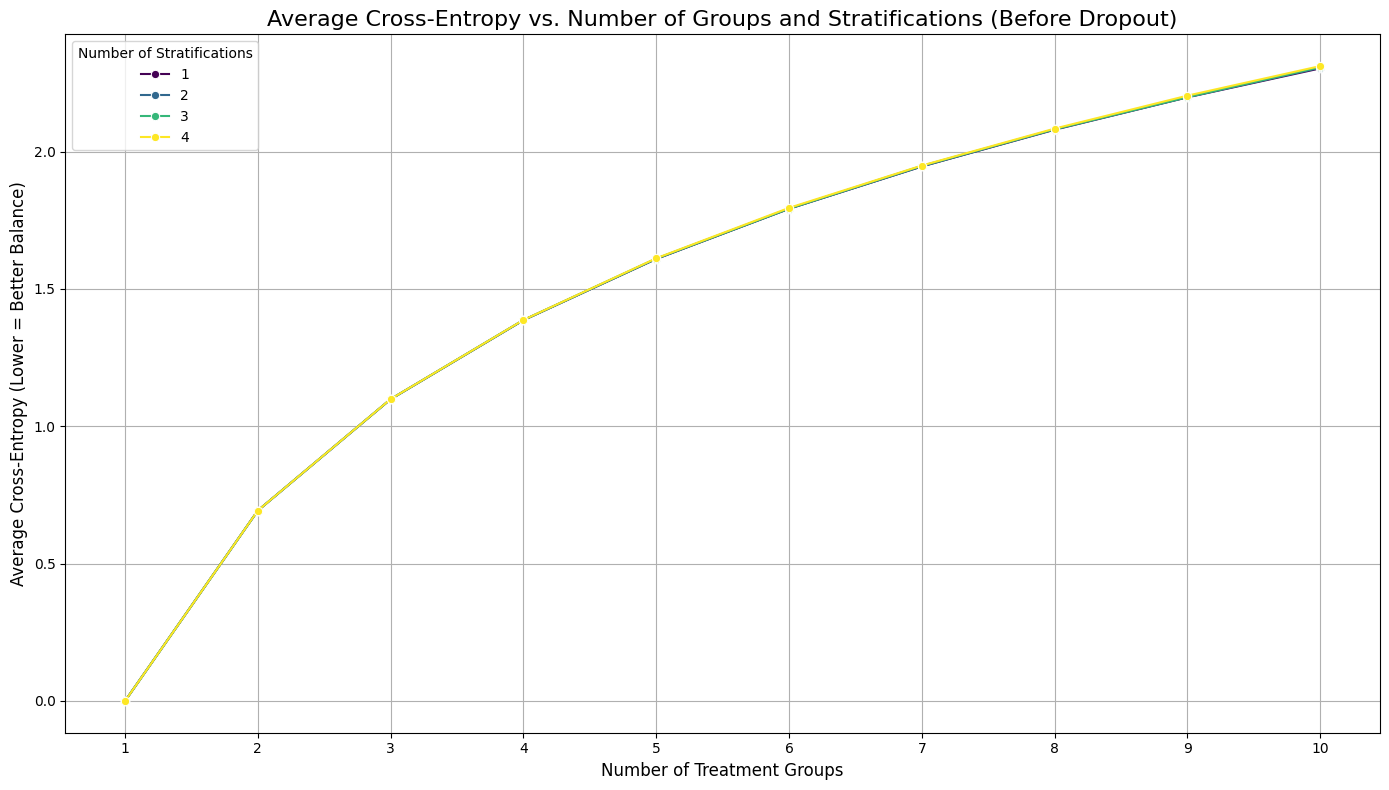

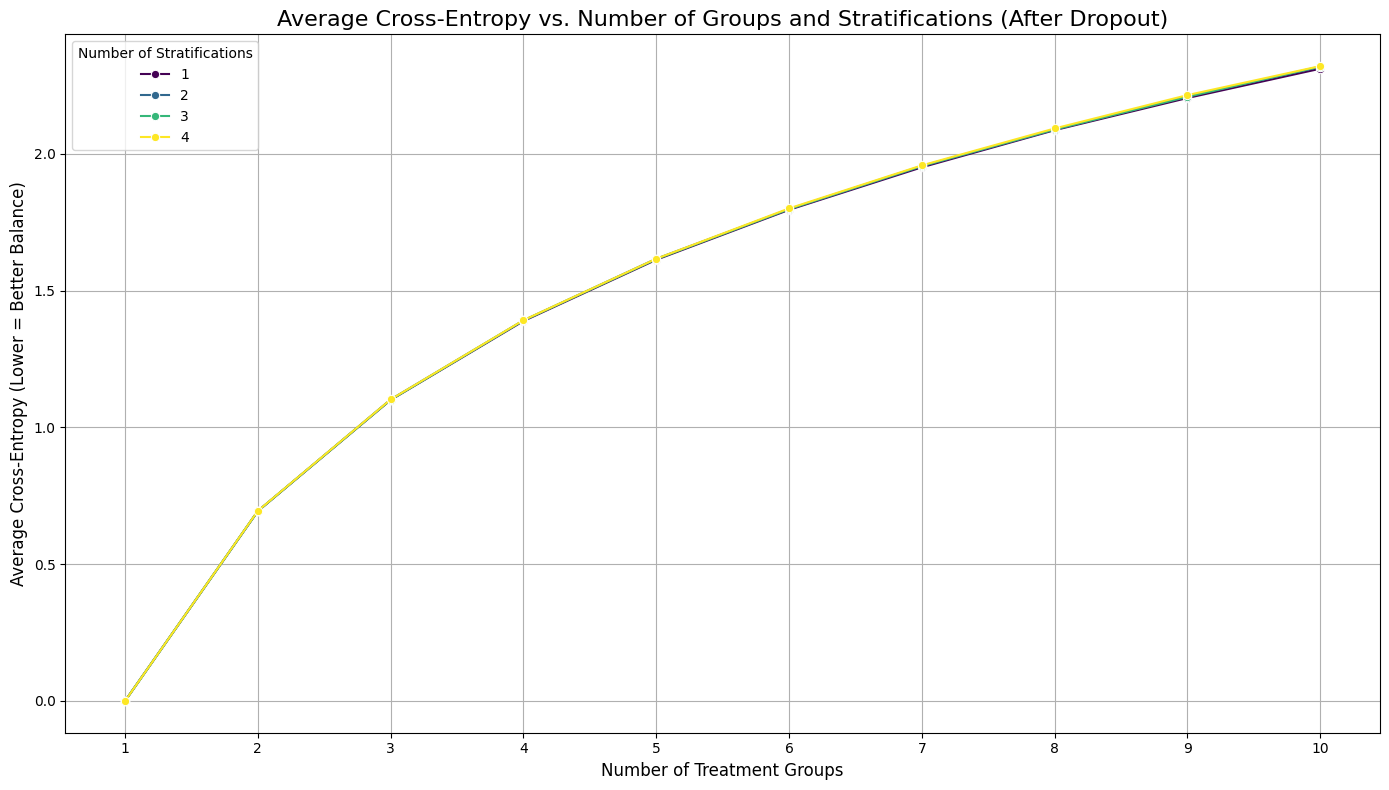

In [11]:
# --- Workflow 4: Simulate and Plot Cross-Entropy vs. Groups and Strata ---

INPUT_FILENAME = '/content/2.csv'
CATEGORICAL_STRATA_OPTIONS = ['W_Strat', 'C_Strat', 'Medication Status', 'Diagnosis'] # Available strata
NUM_STRATA_RANGE = range(1, len(CATEGORICAL_STRATA_OPTIONS) + 1) # Simulate using 1 to 4 strata
NUM_GROUPS_RANGE = range(1, 11) # Simulate using 1 to 10 groups
NUM_SIMULATIONS_PER_COMBINATION = 10 # Number of runs to average for stability
DROPOUT_RATE = 0.15 # Simulate a 15% dropout rate

results = []

print("--- Workflow 4: Running Simulations for Cross-Entropy Analysis ---")

# Preprocess data once
try:
    preprocessed_df = preprocess_data(INPUT_FILENAME)
except FileNotFoundError:
    print(f"\nERROR: The file '{INPUT_FILENAME}' was not found.")
    print("Please make sure you have uploaded the file to your Colab session.")
    # Exit the script or handle the error appropriately for a workflow cell
    raise # Re-raise the exception to stop execution if file not found
except KeyError as e:
    print(f"\nERROR: A required column was not found during preprocessing: {e}")
    print("Please check your CSV file's column headers.")
    raise # Re-raise the exception


# Iterate through number of strata
for num_strata in NUM_STRATA_RANGE:
    # Select the first 'num_strata' variables as the strata for this run
    current_strata_vars = CATEGORICAL_STRATA_OPTIONS[:num_strata]
    print(f"\nSimulating with {num_strata} strata: {current_strata_vars}")

    # Iterate through number of groups
    for num_groups in NUM_GROUPS_RANGE:
        print(f"  Testing {num_groups} groups...", end="")
        cross_entropies_before_dropout = []
        cross_entropies_after_dropout = []

        # Run multiple simulations for averaging
        for _ in range(NUM_SIMULATIONS_PER_COMBINATION):
            # Need a fresh copy of the dataframe for each randomization run
            df_copy = preprocessed_df.copy()

            # Run randomization (before dropout)
            randomized_df = map_coloring_randomization(df_copy, current_strata_vars, num_groups)
            avg_ce_before = calculate_average_cross_entropy(randomized_df, current_strata_vars, num_groups)
            if not np.isnan(avg_ce_before):
                cross_entropies_before_dropout.append(avg_ce_before)

            # Simulate dropouts (after randomization)
            n_to_keep = int(len(randomized_df) * (1 - DROPOUT_RATE))
            if n_to_keep == 0:
                 df_after_dropouts = pd.DataFrame(columns=randomized_df.columns)
            else:
                df_after_dropouts = randomized_df.sample(n=n_to_keep).reset_index(drop=True)


            # Calculate cross-entropy after dropout
            # Need to recalculate for the remaining participants, using the original strata variables
            # and the number of groups the *original* full dataset was randomized into.
            # The map_coloring_randomization function is not needed here, just the metric calculation.

            avg_ce_after = calculate_average_cross_entropy(df_after_dropouts, current_strata_vars, num_groups)
            if not np.isnan(avg_ce_after):
                cross_entropies_after_dropout.append(avg_ce_after)


        if cross_entropies_before_dropout:
            avg_cross_entropy_for_combo_before = np.mean(cross_entropies_before_dropout)
            results.append({
                'Num_Strata': num_strata,
                'Num_Groups': num_groups,
                'Average_Cross_Entropy': avg_cross_entropy_for_combo_before,
                'Scenario': 'Before Dropout'
            })
            print(f" Avg CE (Before): {avg_cross_entropy_for_combo_before:.4f}", end="")

        if cross_entropies_after_dropout:
            avg_cross_entropy_for_combo_after = np.mean(cross_entropies_after_dropout)
            results.append({
                'Num_Strata': num_strata,
                'Num_Groups': num_groups,
                'Average_Cross_Entropy': avg_cross_entropy_for_combo_after,
                'Scenario': 'After Dropout'
            })
            print(f" Avg CE (After): {avg_cross_entropy_for_combo_after:.4f}")
        else:
             print(" No valid data for CE (After).")


results_df = pd.DataFrame(results)

print("\n--- Simulation Complete ---")
print("Simulation Results Head:")
print(results_df.head())

# --- Plotting Results ---
print("\n--- Generating Plots ---")

if not results_df.empty:
    # Plot for Before Dropout
    plt.figure(figsize=(14, 8))
    subset_before = results_df[results_df['Scenario'] == 'Before Dropout'].copy() # Use .copy() to avoid SettingWithCopyWarning
    sns.lineplot(
        data=subset_before,
        x='Num_Groups',
        y='Average_Cross_Entropy',
        hue='Num_Strata',
        marker='o',
        palette='viridis' # Using a perceptually uniform palette
    )
    plt.title('Average Cross-Entropy vs. Number of Groups and Stratifications (Before Dropout)', fontsize=16)
    plt.xlabel('Number of Treatment Groups', fontsize=12)
    plt.ylabel('Average Cross-Entropy (Lower = Better Balance)', fontsize=12)
    plt.xticks(NUM_GROUPS_RANGE)
    plt.grid(True)
    plt.legend(title='Number of Stratifications')
    plt.tight_layout()
    plt.show()

    # Plot for After Dropout
    plt.figure(figsize=(14, 8))
    subset_after = results_df[results_df['Scenario'] == 'After Dropout'].copy() # Use .copy() to avoid SettingWithCopyWarning
    sns.lineplot(
        data=subset_after,
        x='Num_Groups',
        y='Average_Cross_Entropy',
        hue='Num_Strata',
        marker='o',
        palette='viridis' # Using the same palette for consistency
    )
    plt.title('Average Cross-Entropy vs. Number of Groups and Stratifications (After Dropout)', fontsize=16)
    plt.xlabel('Number of Treatment Groups', fontsize=12)
    plt.ylabel('Average Cross-Entropy (Lower = Better Balance)', fontsize=12)
    plt.xticks(NUM_GROUPS_RANGE)
    plt.grid(True)
    plt.legend(title='Number of Stratifications')
    plt.tight_layout()
    plt.show()

else:
    print("No results to plot.")

--- 1. Preprocessing Data ---
Normalized 'Age' and 'BMI' using Z-score.
   ParticipantID       Age       BMI
0              1  0.163672 -0.362840
1              2  0.792784  0.977804
2              4  1.421896  0.519163
3              5 -0.105948  1.401166
4              6 -1.543919 -1.632925

--- 2. Running Map Coloring Randomization ---
Randomization complete. Assigned 246 participants to 5 groups.

               BALANCE METRICS FOR FULL COHORT (BEFORE DROPOUT)

--- 3. Calculating Balance Metrics (Validation) ---
Overall Group Sizes:
Assigned_Group
Group 1    48
Group 2    52
Group 3    49
Group 4    49
Group 5    48
Name: count, dtype: int64

--- Categorical Balance ---

--- Balance for 'W_Strat' ---
Assigned_Group  Group 1  Group 2  Group 3  Group 4  Group 5
W_Strat                                                    
Healthy              23       25       22       23       22
Obese                25       27       27       26       26
Chi-Squared Test: chi2=0.15, p-value=0.997
Ave

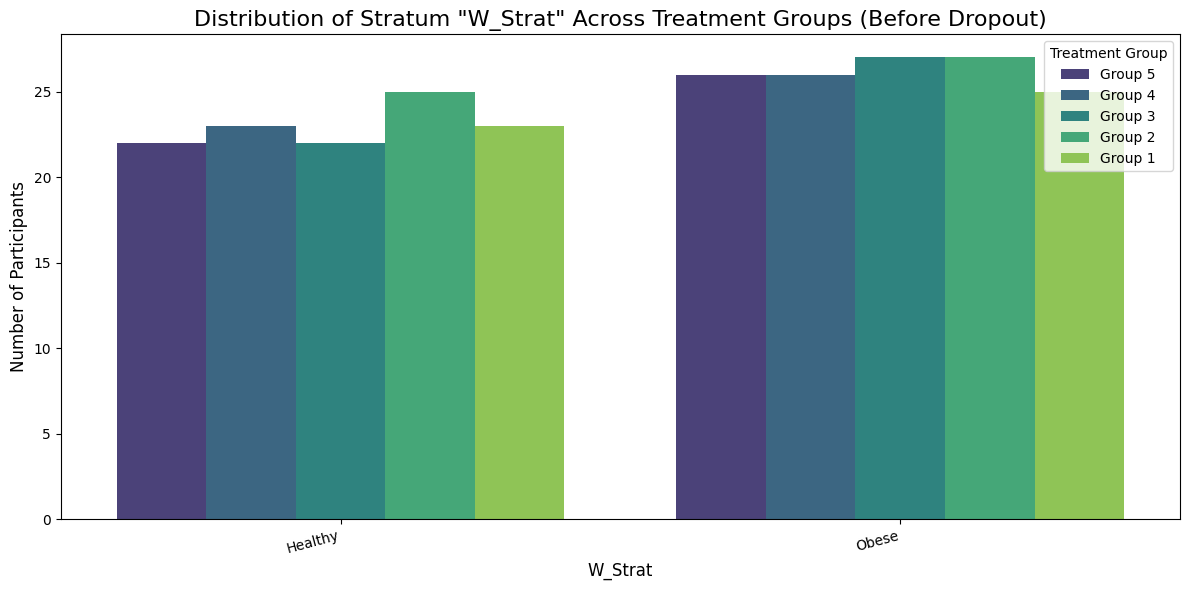

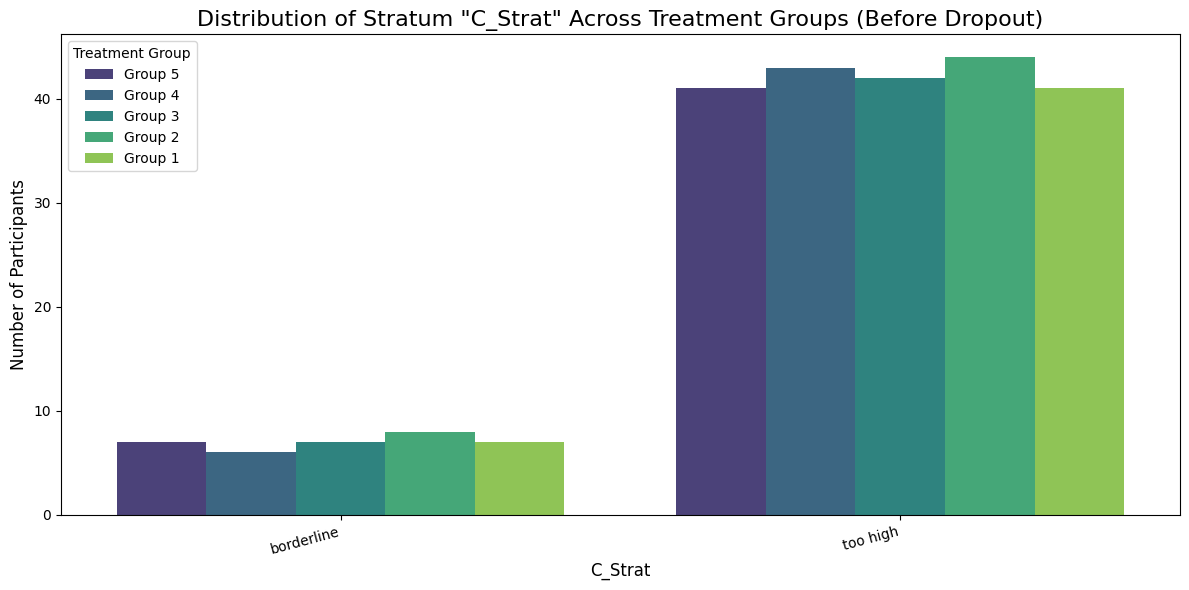

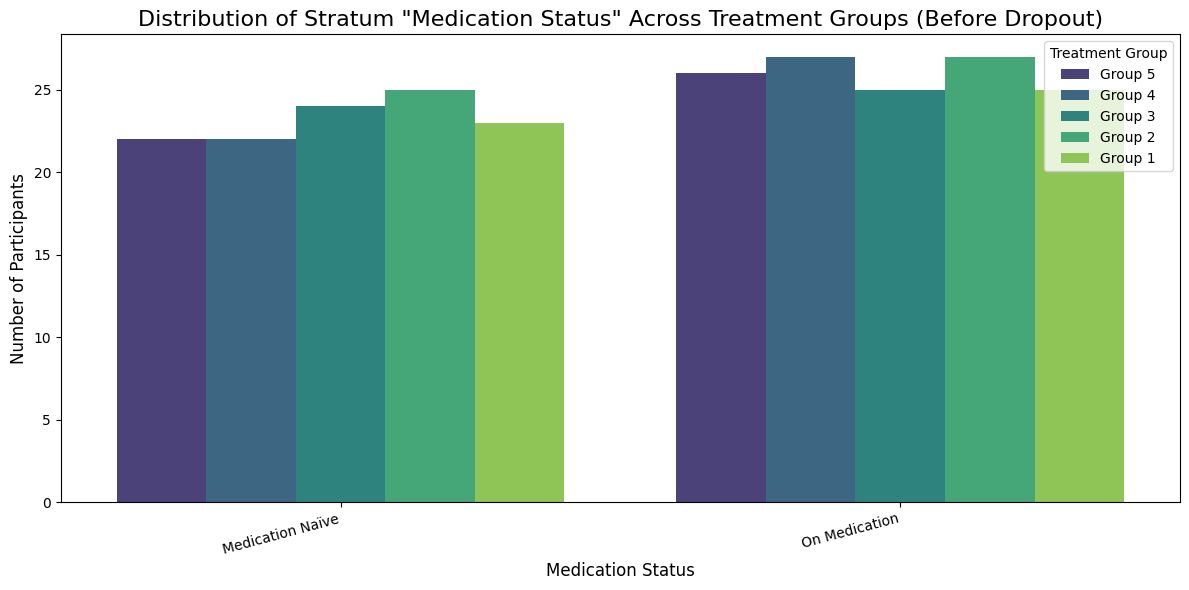

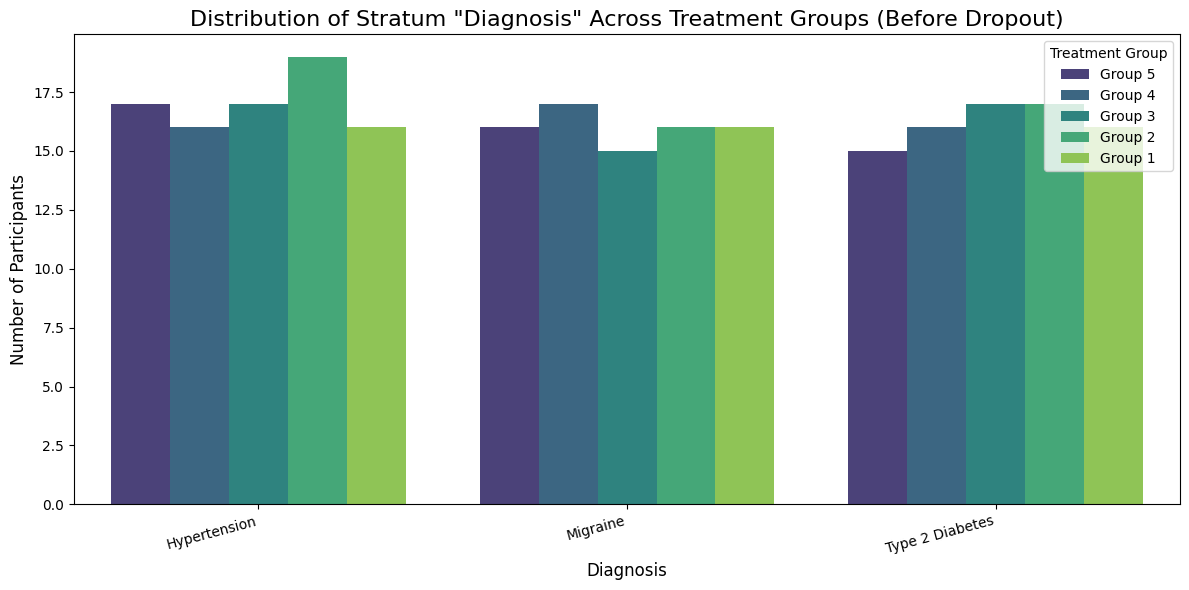

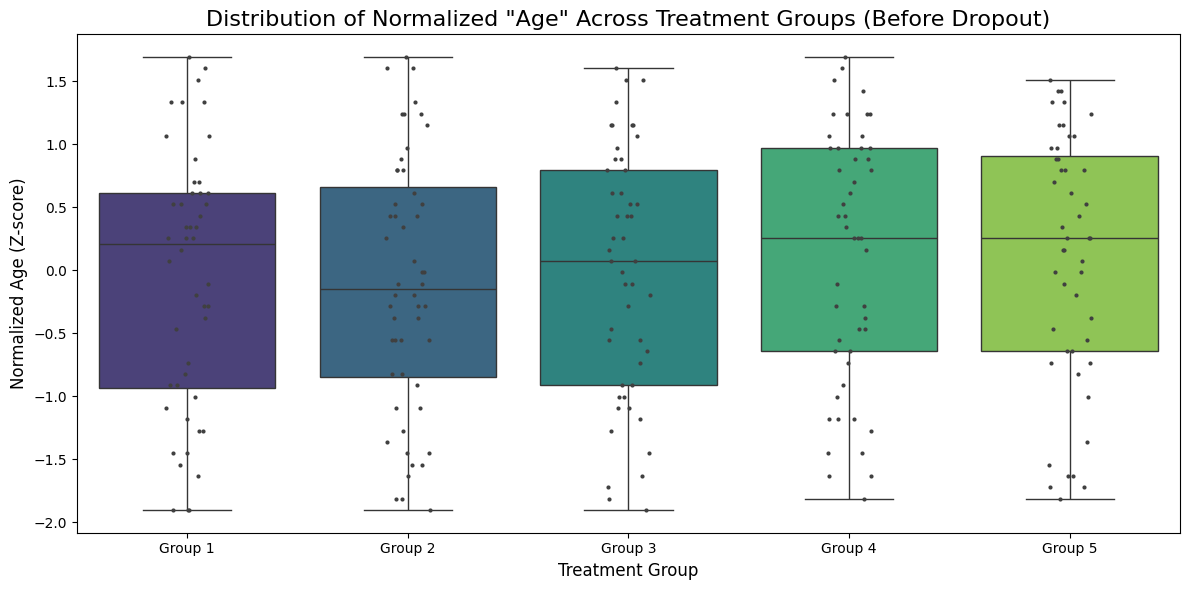

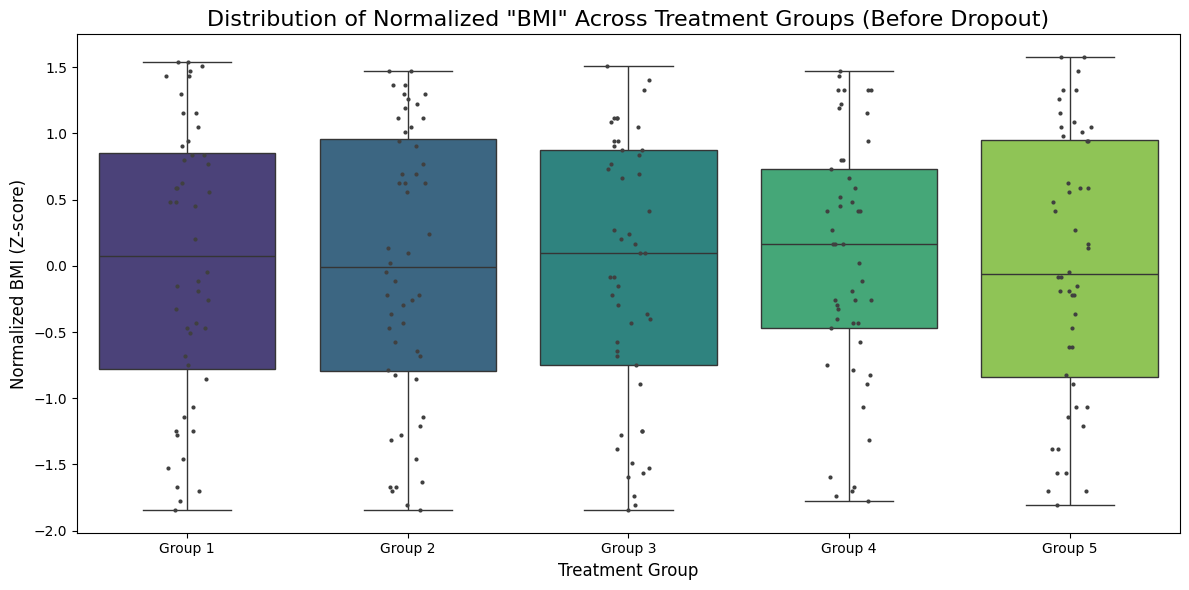


               BALANCE METRICS FOR REMAINING COHORT (AFTER DROPOUT)

--- 5. Simulating 15% Participant Dropout ---
Simulated 36 dropouts. 210 participants remain in the trial.

--- Recalculating Balance Metrics After Dropouts ---

--- 3. Calculating Balance Metrics (Validation) ---
Overall Group Sizes:
Assigned_Group
Group 1    40
Group 2    45
Group 3    41
Group 4    42
Group 5    42
Name: count, dtype: int64

--- Categorical Balance ---

--- Balance for 'W_Strat' ---
Assigned_Group  Group 1  Group 2  Group 3  Group 4  Group 5
W_Strat                                                    
Healthy              19       24       18       21       20
Obese                21       21       23       21       22
Chi-Squared Test: chi2=0.83, p-value=0.934
Average Cross-Entropy: 1.6122 (lower is better)

--- Balance for 'C_Strat' ---
Assigned_Group  Group 1  Group 2  Group 3  Group 4  Group 5
C_Strat                                                    
borderline            4        8        6 

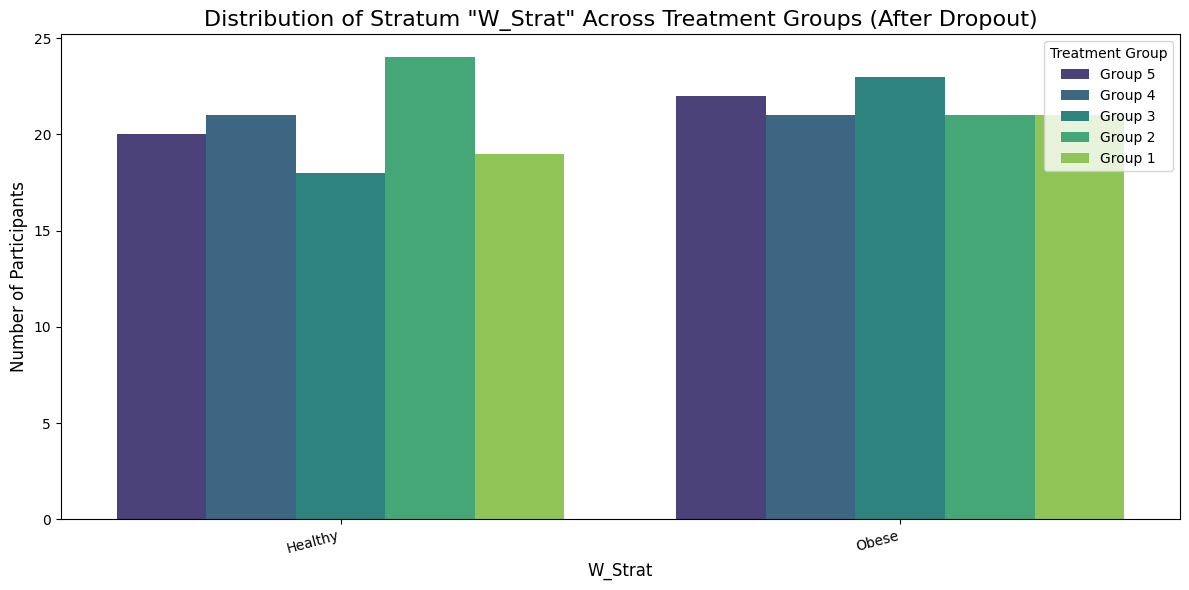

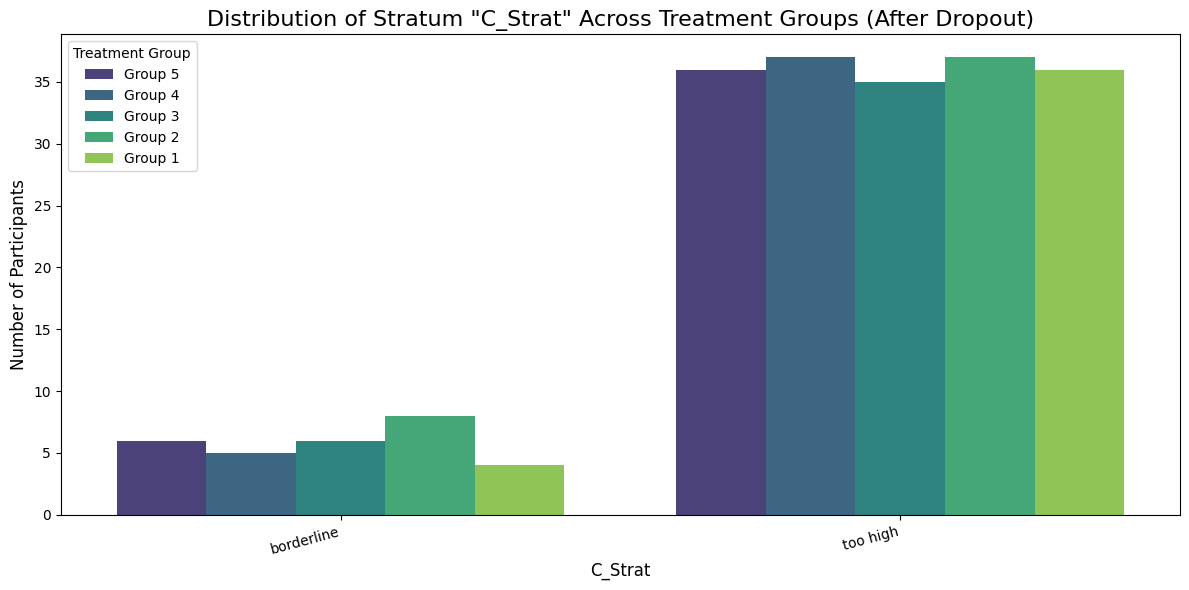

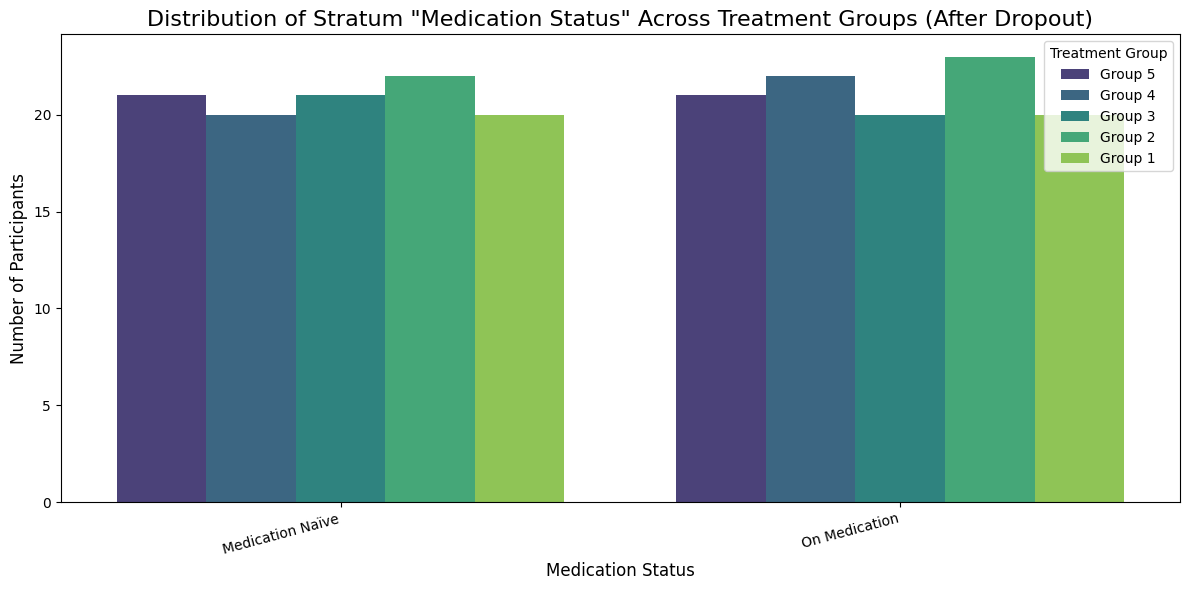

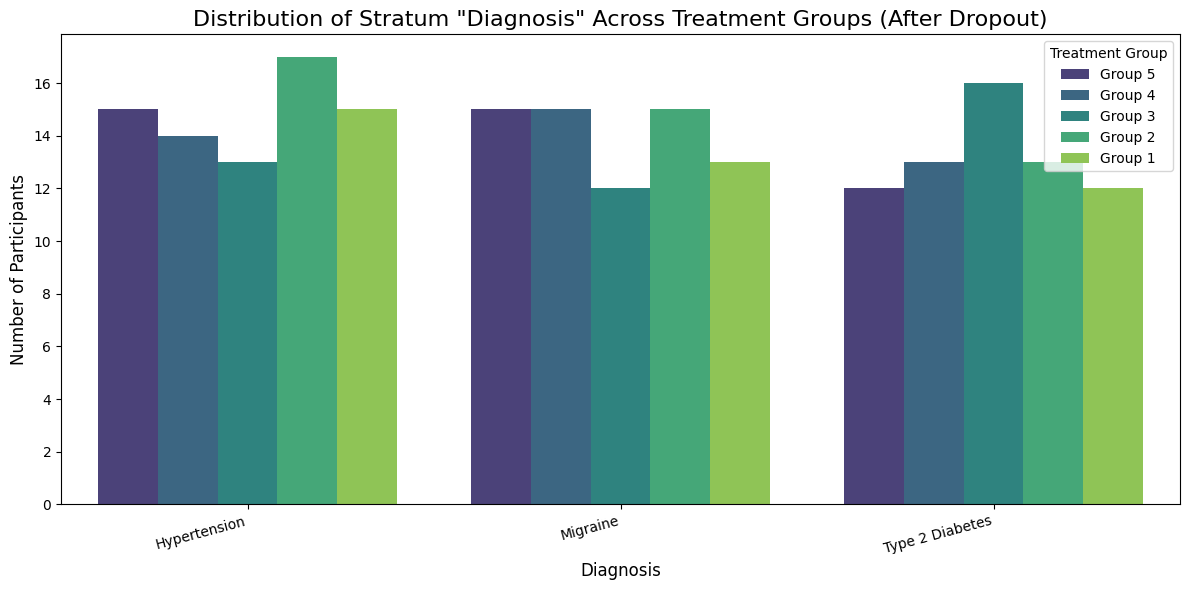

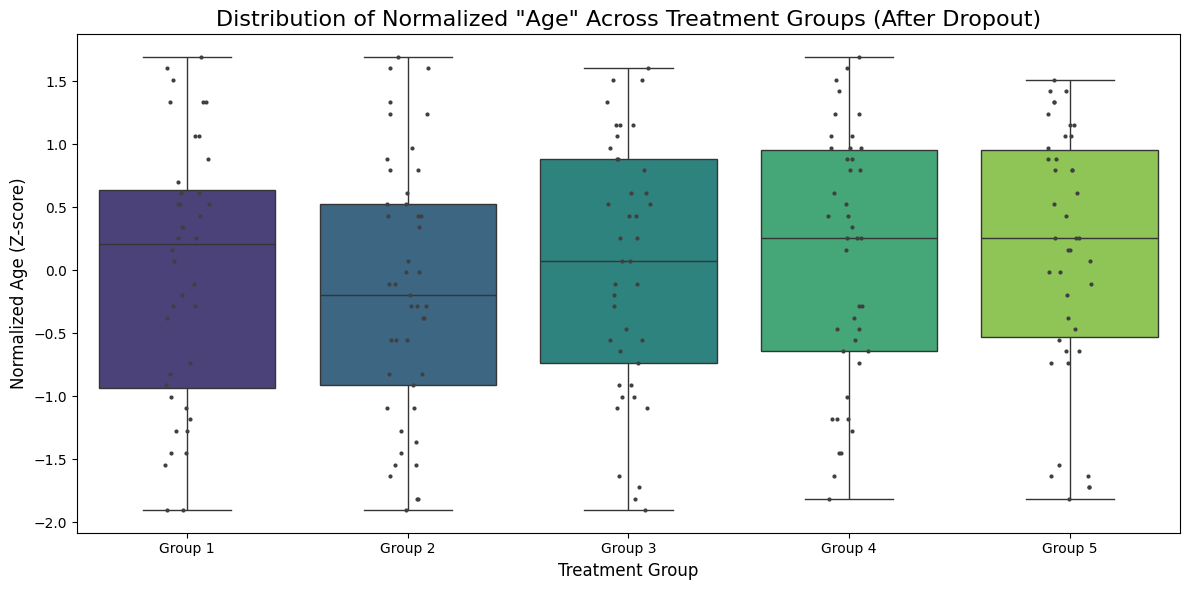

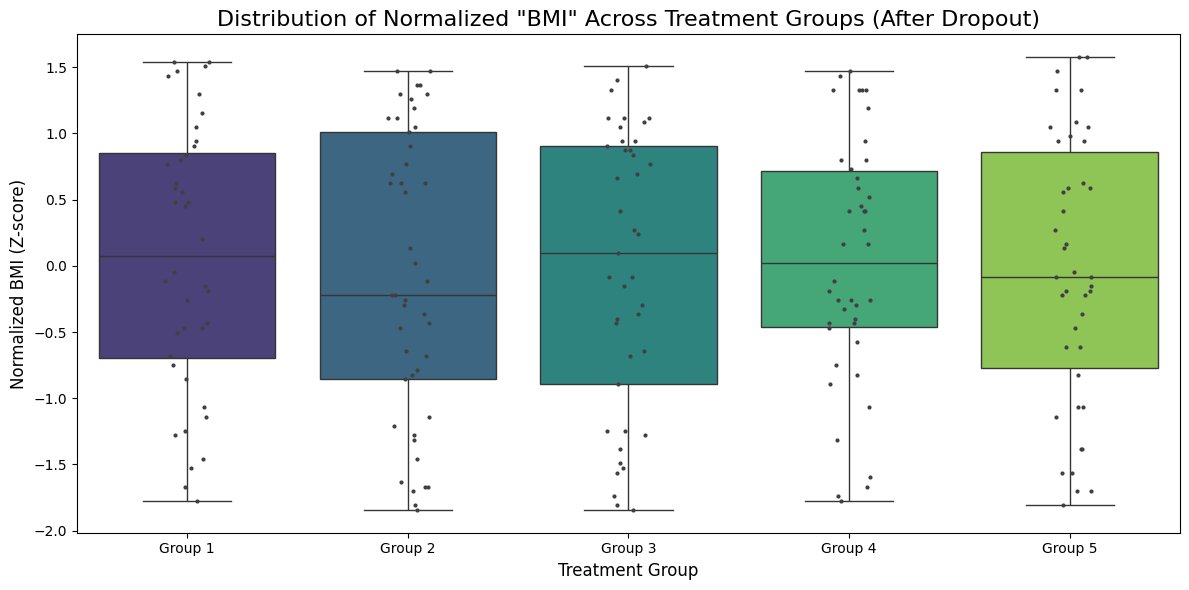


--- Pipeline Complete. ---
Original randomized data (pre-dropout) saved to 'randomized_participants.csv'.
Final Randomized Data Head:
   ParticipantID              Name  W_Strat   C_Strat Medication Status  \
0              1  Michael Thompson  Healthy  too high     On Medication   
1              2    Jessica Garcia    Obese  too high  Medication Naïve   
2              4       Laura Davis    Obese  too high     On Medication   
3              5    David Martinez    Obese  too high  Medication Naïve   
4              6       Emily Brown  Healthy  too high     On Medication   

         Diagnosis Assigned_Group  
0     Hypertension        Group 5  
1  Type 2 Diabetes        Group 5  
2     Hypertension        Group 4  
3  Type 2 Diabetes        Group 3  
4         Migraine        Group 2  


In [12]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from scipy.stats import chi2_contingency, f_oneway
from scipy.spatial.distance import pdist, squareform
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Suppress pandas warnings for cleaner output
warnings.filterwarnings('ignore', category=FutureWarning)

# --- INSTRUCTIONS FOR GOOGLE COLAB ---
# 1. Upload your CSV file ('/content/2.csv') to your Colab session.
# 2. Run this entire script cell.
# 3. The script will output balance statistics and visualizations.
# 4. A new file 'randomized_participants.csv' will be created and can be downloaded.

# --- Part 1: Data Preprocessing & Covariate Normalization ---
def preprocess_data(file_path):
    """
    Loads, cleans, preprocesses, and normalizes the participant data.
    """
    print("--- 1. Preprocessing Data ---")
    df = pd.read_csv(file_path)

    # Drop participants who are not enrolled
    df = df[df['Enrollment Status'] == 'Enrolled'].reset_index(drop=True)

    # Define cholesterol stratification
    def stratify_cholesterol(level):
        if level < 100: return 'ideal'
        if 100 <= level <= 160: return 'borderline'
        return 'too high'

    df['C_Strat'] = df['Cholesterol Level (mg/dL)'].apply(stratify_cholesterol)

    # Normalize continuous covariates using z-score
    continuous_covariates = ['Age', 'BMI']
    scaler = StandardScaler()
    df[continuous_covariates] = scaler.fit_transform(df[continuous_covariates])
    print("Normalized 'Age' and 'BMI' using Z-score.")
    print(df[['ParticipantID', 'Age', 'BMI']].head())
    return df

# --- Part 3: Map Coloring-Based Assignment ---
def map_coloring_randomization(df, strata_vars, num_groups=5):
    """
    Performs stratified randomization using a map coloring analogy.
    Each unique combination of strata is a "region". Participants within each
    region are assigned "colors" (treatment groups) to ensure balance.
    This is equivalent to permuted block randomization within each stratum.
    """
    print("\n--- 2. Running Map Coloring Randomization ---")

    treatment_groups = [f'Group {i+1}' for i in range(num_groups)]
    assignments = pd.Series(index=df.index, dtype=str)

    # Create a composite stratum ("region") for each participant
    # This combines all stratification variables into a single identifier
    composite_strata = df[strata_vars].apply(lambda x: '_'.join(x.astype(str)), axis=1)

    # Iterate over each unique "region"
    for stratum in composite_strata.unique():
        # Get the indices of all participants in the current region
        participant_indices_in_stratum = df[composite_strata == stratum].index.tolist()

        # Randomly shuffle the order of participants within the region
        np.random.shuffle(participant_indices_in_stratum)

        # Create a balanced, shuffled block of treatment assignments ("colors")
        num_participants = len(participant_indices_in_stratum)
        block_size = num_groups

        # Generate enough full blocks to cover all participants
        num_blocks = (num_participants + block_size - 1) // block_size
        assignment_block = []
        for _ in range(num_blocks):
            shuffled_groups = treatment_groups.copy()
            np.random.shuffle(shuffled_groups)
            assignment_block.extend(shuffled_groups)

        # Trim the assignment block to the exact number of participants
        final_assignments = assignment_block[:num_participants]

        # Assign the "colors" to the participants in the region
        assignments.loc[participant_indices_in_stratum] = final_assignments

    # Add assignment column to the dataframe
    df['Assigned_Group'] = assignments
    print(f"Randomization complete. Assigned {len(df)} participants to {num_groups} groups.")
    return df

# --- Part 6: Simulation and Validation Framework ---
def cross_entropy(observed, expected):
    """Calculates cross-entropy between observed and expected distributions."""
    return -np.sum(expected * np.log(observed + 1e-9)) # Add small epsilon to avoid log(0)

def calculate_average_cross_entropy(df, strata_vars, num_groups):
    """
    Calculates the average cross-entropy across specified strata variables.
    Returns NaN if no data or no groups are present.
    """
    if df.empty or 'Assigned_Group' not in df.columns or num_groups == 0:
        return np.nan

    expected_dist = [1/num_groups] * num_groups
    total_entropy = 0
    num_valid_strata = 0

    for var in strata_vars:
        if df[var].nunique() > 0:
            contingency_table = pd.crosstab(df[var], df['Assigned_Group'])
            if contingency_table.shape[0] > 0 and contingency_table.shape[1] > 0:
                for stratum_value in contingency_table.index:
                    observed_dist = contingency_table.loc[stratum_value] / contingency_table.loc[stratum_value].sum()
                    # Ensure observed_dist has the same length as expected_dist, filling with 0 if groups are missing
                    observed_dist = observed_dist.reindex([f'Group {i+1}' for i in range(num_groups)], fill_value=0).values
                    total_entropy += cross_entropy(observed_dist, expected_dist)
                num_valid_strata += len(contingency_table)

    if num_valid_strata > 0:
        return total_entropy / num_valid_strata
    else:
        return np.nan # Return NaN if no valid strata data to calculate entropy

def calculate_tanimoto_similarity(df, strata_vars, num_groups):
    """Calculates and prints pairwise Tanimoto similarity between all groups."""
    print("\n--- Tanimoto Pairwise Similarity ---")

    if df.empty or 'Assigned_Group' not in df.columns:
        print("  (Skipping Tanimoto similarity: No data available)")
        return

    # Create a feature matrix using one-hot encoding for all categorical strata
    feature_df = pd.get_dummies(df[['Assigned_Group'] + strata_vars], columns=strata_vars)

    # Sum the features for each group to get a single vector per group
    group_vectors = feature_df.groupby('Assigned_Group').sum()

    # Ensure all possible groups are present, even if empty after dropout
    all_groups = [f'Group {i+1}' for i in range(num_groups)]
    group_vectors = group_vectors.reindex(all_groups, fill_value=0)

    try:
        # pdist computes Jaccard distance; we convert it to similarity (1 - distance)
        dist_matrix = pdist(group_vectors.values, metric='jaccard')
        sim_matrix = 1 - squareform(dist_matrix)

        sim_df = pd.DataFrame(sim_matrix, index=group_vectors.index, columns=group_vectors.index)

        print("Similarity Matrix (1 = perfectly similar):")
        print(sim_df.round(4))
        avg_similarity = 1 - np.mean(dist_matrix)
        print(f"Average Pairwise Similarity: {avg_similarity:.4f} (higher is better)")

    except ValueError as e:
        print(f"  (Could not compute Tanimoto similarity: {e})")


def calculate_balance_metrics(df, strata_vars, continuous_vars, num_groups):
    """
    Calculates and prints statistics to validate the balance of the randomization.
    """
    print("\n--- 3. Calculating Balance Metrics (Validation) ---")

    # Overall distribution
    print("Overall Group Sizes:")
    print(df['Assigned_Group'].value_counts().sort_index())

    # --- Categorical Variable Balance ---
    print("\n--- Categorical Balance ---")
    expected_dist = [1/num_groups] * num_groups

    for var in strata_vars:
        print(f"\n--- Balance for '{var}' ---")
        contingency_table = pd.crosstab(df[var], df['Assigned_Group'])
        print(contingency_table)

        # Chi-Squared Test
        if contingency_table.shape[0] > 1 and contingency_table.shape[1] > 1:
            chi2, p, _, _ = chi2_contingency(contingency_table)
            print(f"Chi-Squared Test: chi2={chi2:.2f}, p-value={p:.3f}")
            if p < 0.05:
                print("  (Warning: Potential significant imbalance detected)")
        else:
             print("  (Skipping Chi-Squared test due to insufficient data)")


        # Cross-Entropy Metric
        total_entropy = 0
        num_stratum_values = 0
        if contingency_table.shape[0] > 0 and contingency_table.shape[1] > 0:
            for stratum_value in contingency_table.index:
                observed_dist = contingency_table.loc[stratum_value] / contingency_table.loc[stratum_value].sum()
                # Ensure observed_dist has the same length as expected_dist, filling with 0 if groups are missing
                observed_dist = observed_dist.reindex([f'Group {i+1}' for i in range(num_groups)], fill_value=0).values
                total_entropy += cross_entropy(observed_dist, expected_dist)
                num_stratum_values += 1
            if num_stratum_values > 0:
                print(f"Average Cross-Entropy: {total_entropy / num_stratum_values:.4f} (lower is better)")
            else:
                 print("Average Cross-Entropy: N/A (No valid stratum values)")
        else:
             print("Average Cross-Entropy: N/A (Insufficient data for contingency table)")



    # --- Continuous Variable Balance ---
    print("\n--- Continuous Balance (Z-scores) ---")
    for var in continuous_vars:
        print(f"\n--- Balance for '{var}' ---")
        # Ensure all possible groups are included, even if empty
        all_groups = sorted([f'Group {i+1}' for i in range(num_groups)])
        groups_data = [df[var][df['Assigned_Group'] == g].dropna() for g in all_groups]

        for i, g in enumerate(all_groups):
            mean_val = np.mean(groups_data[i]) if len(groups_data[i]) > 0 else np.nan
            std_val = np.std(groups_data[i]) if len(groups_data[i]) > 0 else np.nan
            print(f"  {g}: Mean={mean_val:.3f}, Std={std_val:.3f}")

        # ANOVA Test - filter out empty groups
        valid_groups_data = [g for g in groups_data if len(g) > 0]
        if len(valid_groups_data) > 1:
            f_stat, p = f_oneway(*valid_groups_data)
            print(f"ANOVA Test: F-statistic={f_stat:.2f}, p-value={p:.3f}")
            if p < 0.05:
                print("  (Warning: Potential significant imbalance detected in means)")
        else:
            print("  (Skipping ANOVA test due to insufficient data in groups)")


# --- Part 7: Visualization of Treatment Assignment ---
def visualize_balance(df, strata_vars, continuous_vars, title_suffix=""):
    """
    Creates visualizations to show the distribution of assignments.
    Includes a title suffix for clarity.
    """
    print(f"\n--- 4. Generating Visualizations{title_suffix} ---")

    num_groups = df['Assigned_Group'].nunique()
    if num_groups == 0:
        print("No participants to visualize.")
        return

    # Categorical Variable Visualization
    for var in strata_vars:
        plt.figure(figsize=(12, 6))
        sns.countplot(data=df, x=var, hue='Assigned_Group', palette='viridis', order=sorted(df[var].unique()))
        plt.title(f'Distribution of Stratum "{var}" Across Treatment Groups{title_suffix}', fontsize=16)
        plt.xlabel(var, fontsize=12)
        plt.ylabel('Number of Participants', fontsize=12)
        plt.xticks(rotation=15, ha='right')
        plt.legend(title='Treatment Group')
        plt.tight_layout()
        plt.show()

    # Continuous Variable Visualization
    for var in continuous_vars:
        plt.figure(figsize=(12, 6))
        sns.boxplot(data=df, x='Assigned_Group', y=var, palette='viridis', order=sorted(df['Assigned_Group'].unique()))
        sns.stripplot(data=df, x='Assigned_Group', y=var, color=".25", size=3, order=sorted(df['Assigned_Group'].unique()))
        plt.title(f'Distribution of Normalized "{var}" Across Treatment Groups{title_suffix}', fontsize=16)
        plt.xlabel('Treatment Group', fontsize=12)
        plt.ylabel(f'Normalized {var} (Z-score)', fontsize=12)
        plt.tight_layout()
        plt.show()

# --- New Part: Dropout Simulation ---
def simulate_dropouts_and_revalidate(df, dropout_rate, strata_vars, continuous_vars, num_groups):
    """
    Simulates random participant dropouts and recalculates balance metrics.
    """
    if not (0 <= dropout_rate < 1):
        print("\nDropout rate must be between 0 and 1. Skipping simulation.")
        return

    print(f"\n--- 5. Simulating {dropout_rate*100:.0f}% Participant Dropout ---")

    # Determine the number of participants to drop
    n_participants = len(df)
    n_dropouts = int(n_participants * dropout_rate)

    if n_participants == 0:
        print("No participants to simulate dropout from.")
        df_after_dropouts = pd.DataFrame(columns=df.columns) # Return empty dataframe with same columns
    elif n_dropouts >= n_participants:
         print("Dropout rate is too high, all participants will be dropped.")
         df_after_dropouts = pd.DataFrame(columns=df.columns) # Return empty dataframe with same columns
    else:
        # Randomly select indices to drop
        dropout_indices = np.random.choice(df.index, n_dropouts, replace=False)
        # Create a new dataframe for the remaining participants
        df_after_dropouts = df.drop(dropout_indices).reset_index(drop=True)

    print(f"Simulated {n_dropouts} dropouts. {len(df_after_dropouts)} participants remain in the trial.")

    # Recalculate balance metrics on the remaining cohort
    print("\n--- Recalculating Balance Metrics After Dropouts ---")
    # Ensure num_groups is passed correctly
    calculate_balance_metrics(df_after_dropouts, strata_vars, continuous_vars, num_groups)
    # Add Tanimoto Similarity calculation after dropout
    calculate_tanimoto_similarity(df_after_dropouts, strata_vars, num_groups)
    return df_after_dropouts # Return the dataframe after dropouts


# --- Main Execution: Chaining the Prompts for a Full Pipeline ---
if __name__ == '__main__':
    # Define parameters
    INPUT_FILENAME = '/content/2.csv'
    OUTPUT_FILENAME = 'randomized_participants.csv'
    CATEGORICAL_STRATA = ['W_Strat', 'C_Strat', 'Medication Status', 'Diagnosis']
    CONTINUOUS_COVARIATES = ['Age', 'BMI']
    NUM_TREATMENT_GROUPS = 5
    DROPOUT_RATE = 0.15 # Simulate a 15% dropout rate

    try:
        # 1. Preprocess data
        preprocessed_df = preprocess_data(INPUT_FILENAME)

        # 2. Run randomization
        randomized_df = map_coloring_randomization(
            preprocessed_df,
            strata_vars=CATEGORICAL_STRATA,
            num_groups=NUM_TREATMENT_GROUPS
        )

        # 3. Calculate balance metrics (Before Dropout)
        print("\n" + "="*80)
        print(" " * 15 + "BALANCE METRICS FOR FULL COHORT (BEFORE DROPOUT)")
        print("="*80)
        calculate_balance_metrics(
            randomized_df,
            strata_vars=CATEGORICAL_STRATA,
            continuous_vars=CONTINUOUS_COVARIATES,
            num_groups=NUM_TREATMENT_GROUPS
        )
        # Add Tanimoto Similarity calculation before dropout
        calculate_tanimoto_similarity(randomized_df, CATEGORICAL_STRATA, NUM_TREATMENT_GROUPS)


        # 4. Visualize the results (Before Dropout)
        visualize_balance(
            randomized_df,
            strata_vars=CATEGORICAL_STRATA,
            continuous_vars=CONTINUOUS_COVARIATES,
            title_suffix=" (Before Dropout)"
        )


        # 5. Simulate dropouts and re-validate the balance
        print("\n" + "="*80)
        print(" " * 15 + "BALANCE METRICS FOR REMAINING COHORT (AFTER DROPOUT)")
        print("="*80)
        df_after_dropouts = simulate_dropouts_and_revalidate(
            randomized_df.copy(), # Pass a copy to avoid modifying randomized_df
            DROPOUT_RATE,
            CATEGORICAL_STRATA,
            CONTINUOUS_COVARIATES,
            NUM_TREATMENT_GROUPS
        )

        # 6. Visualize the results (After Dropout)
        visualize_balance(
            df_after_dropouts,
            strata_vars=CATEGORICAL_STRATA,
            continuous_vars=CONTINUOUS_COVARIATES,
            title_suffix=" (After Dropout)"
        )


        # 7. Save the final randomized dataframe (pre-dropout)
        randomized_df.to_csv(OUTPUT_FILENAME, index=False)
        print(f"\n--- Pipeline Complete. ---")
        print(f"Original randomized data (pre-dropout) saved to '{OUTPUT_FILENAME}'.")
        print("Final Randomized Data Head:")
        print(randomized_df[['ParticipantID', 'Name'] + CATEGORICAL_STRATA + ['Assigned_Group']].head())

    except FileNotFoundError:
        print(f"\nERROR: The file '{INPUT_FILENAME}' was not found.")
        print("Please make sure you have uploaded the file to your Colab session.")
    except KeyError as e:
        print(f"\nERROR: A required column was not found: {e}")
        print("Please check your CSV file's column headers.")

thanks Vaibhav...love you bhai :)